In [26]:
import pandas as pd
reliance_ml_data = pd.read_csv("final_datasets/reliance_final_data.csv")
HDFC_ml_data = pd.read_csv("final_datasets/HDFC_final_data.csv")
MM_ml_data = pd.read_csv("final_datasets/MM_final_data.csv")
INFY_ml_data = pd.read_csv("final_datasets/INFY_final_data.csv")
HUL_ml_data = pd.read_csv("final_datasets/HUL_final_data.csv")
BHARTIARTL_ml_data = pd.read_csv("final_datasets/BHARTIARTL_final_data.csv")


In [27]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import RobustScaler
# from sklearn.metrics import r2_score, accuracy_score
# from lightgbm import LGBMRegressor
# import lightgbm as lgb
# import warnings
# warnings.filterwarnings("ignore")

# RANDOM_STATE = 42



# # ============================================================
# # DATA PREPARATION
# # ============================================================

# def prepare_stock_dataframe(df, name):

#     print(f"\nPreparing data for {name}...")
#     df = df.copy()

#     # 1️⃣ Date formatting
#     df["Date"] = pd.to_datetime(df["Date"])
#     df = df.sort_values("Date").reset_index(drop=True)

#     df.drop(columns=["QuarterDate", "Period",
#                      "Standing Deposit Facility (SDF) Rate (%)"],
#             inplace=True, errors="ignore")

#     if "Depreciation" in df.columns and name == "HDFC":
#         df.drop(columns=["Depreciation"], inplace=True, errors="ignore")

#     # 2️⃣ Clean numeric columns
#     for col in df.columns:
#         if df[col].dtype == "object":
#             df[col] = df[col].str.replace(",", "", regex=False)
#             df[col] = df[col].replace(["-", "--", ""], np.nan)
#             df[col] = pd.to_numeric(df[col], errors="coerce")

#     # 3️⃣ Stationary log return target (next-day)
#     df["log_return"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
#     df["target"] = df["log_return"].shift(-1)

#     # 4️⃣ Lag macro & sentiment to remove look-ahead bias
#     macro_cols = [
#         "USDINR", "USDINR_ret", "CRUDE_ret", "CRUDE", "Bond_Yield", "Period",
#         "Forward Premia of US$ 1-month (%)", "Forward Premia of US$ 3-month (%)",
#         "Forward Premia of US$ 6-month (%)", "Reverse Repo Rate (%)",
#         "Marginal Standing Facility (MSF) Rate (%)", "Bank Rate (%)",
#         "Base Rate (%)", "91-Day Treasury Bill (Primary) Yield (%)",
#         "182-Day Treasury Bill (Primary) Yield (%)",
#         "364-Day Treasury Bill (Primary) Yield (%)",
#         "10-Year G-Sec Yield (FBIL) (%)", "Cash Reserve Ratio (%)",
#         "Statutory Liquidity Ratio (%)", "Policy Repo Rate (%)",
#         "Standing Deposit Facility (SDF) Rate (%)",
#         '"Foreign Exchange Reserves \n(US $ Million)"', 'MACRO_sentiment'
#     ]

#     for col in macro_cols:
#         if col in df.columns:
#             df[col] = df[col].shift(1)

#     # ============================================================
#     # 5️⃣ ADVANCED TECHNICAL INDICATORS
#     # ============================================================

#     eps = 1e-9  # avoid divide-by-zero

#     #add sector return also as an indicator for prediction
#     df["sector_return"] = np.log(df["Sector_Close"] / df["Sector_Close"].shift(1))
#     df["sector_return_lag1"] = df["sector_return"].shift(1)

#     # ----- Buying & Selling Pressure -----
#     df["Buying_Pressure"]  = (df["Close"] - df["Low"]) / (df["High"] - df["Low"] + eps)
#     df["Selling_Pressure"] = (df["High"] - df["Close"]) / (df["High"] - df["Low"] + eps)

#     # ----- Simple Moving Averages -----
#     for window in [5, 10, 20, 50]:
#         df[f"SMA_{window}"] = df["Adj Close"].rolling(window).mean()

#     # ----- Exponential Moving Averages -----
#     df["EMA_12"] = df["Adj Close"].ewm(span=12, adjust=False).mean()
#     df["EMA_26"] = df["Adj Close"].ewm(span=26, adjust=False).mean()

#     # ----- MACD -----
#     df["MACD"] = df["EMA_12"] - df["EMA_26"]
#     df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

#     # ----- RSI (14-day) -----
#     delta = df["Adj Close"].diff()
#     gain = delta.where(delta > 0, 0).rolling(14).mean()
#     loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
#     rs = gain / (loss + eps)
#     df["RSI_14"] = 100 - (100 / (1 + rs))

#     # ----- Bollinger Bands -----
#     df["BB_middle"] = df["Adj Close"].rolling(20).mean()
#     df["BB_std"] = df["Adj Close"].rolling(20).std()
#     df["BB_upper"] = df["BB_middle"] + 2 * df["BB_std"]
#     df["BB_lower"] = df["BB_middle"] - 2 * df["BB_std"]

#     df["BB_bandwidth"] = (df["BB_upper"] - df["BB_lower"]) / (df["BB_middle"] + eps)
#     df["BB_pct"] = (df["Adj Close"] - df["BB_lower"]) / (df["BB_upper"] - df["BB_lower"] + eps)

#     # ----- Volatility -----
#     df["Volatility_5"] = df["log_return"].rolling(5).std()
#     df["Volatility_20"] = df["log_return"].rolling(20).std()

#     # ----- Lagged Returns -----
#     for lag in [1, 2, 3, 5]:
#         df[f"log_return_lag{lag}"] = df["log_return"].shift(lag)

#     # ----- Lagged Volume -----
#     for lag in [1, 2, 3, 5]:
#         df[f"volume_lag{lag}"] = df["Volume"].shift(lag)

#     print(f"Technical features created. Total columns: {len(df.columns)}")

#     # Drop NaNs
#     df = df.dropna().reset_index(drop=True)
#     print(f"Data after dropping NaNs: {df.shape}")

#     return df


# # ============================================================
# # MODEL TRAINING
# # ============================================================

# def train_stock_model(df, stock_name):

#     df = df.copy()

#     # 🔵 Date-based split
#     train_df = df[df["Date"] < "2025-07-01"]
#     val_df   = df[(df["Date"] >= "2025-07-01") & (df["Date"] < "2025-10-01")]
#     test_df  = df[df["Date"] >= "2025-10-01"]

#     # Numeric features only
#     numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

#     exclude = ["target","log_return",
#                "Adj Close","Close","High","Low","Open","Sector_Close"]

#     features = [c for c in numeric_cols if c not in exclude]

#     X_train, y_train = train_df[features], train_df["target"]
#     X_val, y_val     = val_df[features], val_df["target"]
#     X_test, y_test   = test_df[features], test_df["target"]

#     # Robust Scaling
#     scaler = RobustScaler()
#     X_train = scaler.fit_transform(X_train)
#     X_val   = scaler.transform(X_val)
#     X_test  = scaler.transform(X_test)

#     # LightGBM Model
#     model = LGBMRegressor(
#         n_estimators=1000,
#         learning_rate=0.1,
#         max_depth=5,
#         random_state=RANDOM_STATE
#     )

#     model.fit(
#         X_train, y_train, 
#         eval_set=[(X_val, y_val)],
#         callbacks=[lgb.early_stopping(50, verbose=False)]
#     )

#     pred_test = model.predict(X_test)

#     r2 = r2_score(y_test, pred_test)
#     acc = accuracy_score((y_test > 0), (pred_test > 0))

#     print(f"\n📊 {stock_name}")
#     print(f"Test R²: {r2:.4f}")
#     print(f"Directional Accuracy: {acc*100:.2f}%")

#     results = pd.DataFrame({
#         "Date": test_df["Date"].values,
#         "Actual": y_test.values,
#         "Predicted": pred_test
#     })

#     return model, scaler, results


# # ============================================================
# # RUN ALL STOCKS
# # ============================================================

# stocks = {
#     "RELIANCE": reliance_ml_data,
#     "HDFC": HDFC_ml_data,
#     "MM": MM_ml_data,
#     "INFY": INFY_ml_data,
#     "HUL": HUL_ml_data,
#     "BHARTI": BHARTIARTL_ml_data
# }

# all_predictions = {}

# for name, data in stocks.items():
#     prepared = prepare_stock_dataframe(data, name)
#     model, scaler, preds = train_stock_model(prepared, name)
#     all_predictions[name] = preds



In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, RobustScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import r2_score, accuracy_score
from lightgbm import LGBMRegressor, LGBMClassifier
from xgboost import XGBRegressor, XGBClassifier
import lightgbm as lgb
from feature_engine.outliers import Winsorizer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
ROLL_WINDOW = 30




# ============================================================
# DATA PREPARATION (YOUR ORIGINAL + RESIDUAL TARGET OPTION)
# ============================================================

def prepare_stock_dataframe(df, name, target_type="residual"):

    print(f"\nPreparing data for {name}...")
    df = df.copy()

    # 1️⃣ Date formatting
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    df.drop(columns=["QuarterDate", "Period",
                     "Standing Deposit Facility (SDF) Rate (%)"],
            inplace=True, errors="ignore")

    if "Depreciation" in df.columns and name == "HDFC":
        df.drop(columns=["Depreciation"], inplace=True, errors="ignore")

    # 2️⃣ Clean numeric columns
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].str.replace(",", "", regex=False)
            df[col] = df[col].replace(["-", "--", ""], np.nan)
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    sentiment_cols = [c for c in df.columns if "sentiment" in c.lower()]

    for col in sentiment_cols:
        df[f"{col}_ema5"] = df[col].ewm(span=5, adjust=False).mean()
        df[f"{col}_ema10"] = df[col].ewm(span=10, adjust=False).mean()
    

    # 3️⃣ Returns
    df["log_return"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
    df["sector_return"] = np.log(df["Sector_Close"] / df["Sector_Close"].shift(1))

    df["return_pct"] = df["Adj Close"] / df["Adj Close"].shift(1) - 1
    df["sector_return_pct"] = df["Sector_Close"]/df["Sector_Close"].shift(1) - 1

    if target_type == "residual":
        df["target"] = (df["return_pct"] - df["sector_return_pct"]).shift(-1)
    else:
        df["target"] = df["log_return"].shift(-1)


    # 4️⃣ Lag macro & sentiment to remove look-ahead bias doing this in data prep instead of feature engineering to ensure all features are aligned and no leakage
    macro_cols = [
        "USDINR", "USDINR_ret", "CRUDE_ret", "CRUDE", "Bond_Yield", "Period",
        "Forward Premia of US$ 1-month (%)", "Forward Premia of US$ 3-month (%)",
        "Forward Premia of US$ 6-month (%)", "Reverse Repo Rate (%)",
        "Marginal Standing Facility (MSF) Rate (%)", "Bank Rate (%)",
        "Base Rate (%)", "91-Day Treasury Bill (Primary) Yield (%)",
        "182-Day Treasury Bill (Primary) Yield (%)",
        "364-Day Treasury Bill (Primary) Yield (%)",
        "10-Year G-Sec Yield (FBIL) (%)", "Cash Reserve Ratio (%)",
        "Statutory Liquidity Ratio (%)", "Policy Repo Rate (%)",
        "Standing Deposit Facility (SDF) Rate (%)",
        '"Foreign Exchange Reserves \n(US $ Million)"', 'MACRO_sentiment'
    ]

    # ============================================================
    # 5️⃣ ADVANCED TECHNICAL INDICATORS
    # ============================================================

    eps = 1e-9  # avoid divide-by-zero

    #add sector return also as an indicator for prediction
    df["sector_return"] = np.log(df["Sector_Close"] / df["Sector_Close"].shift(1))
    df["sector_return_lag1"] = df["sector_return"].shift(1)

    # ----- Buying & Selling Pressure -----
    df["Buying_Pressure"]  = (df["Close"] - df["Low"]) / (df["High"] - df["Low"] + eps)
    df["Selling_Pressure"] = (df["High"] - df["Close"]) / (df["High"] - df["Low"] + eps)

    # ----- Simple Moving Averages -----
    for window in [5, 10, 20, 50]:
        df[f"SMA_{window}"] = df["Adj Close"].rolling(window).mean()

    # ----- Exponential Moving Averages -----
    df["EMA_12"] = df["Adj Close"].ewm(span=12, adjust=False).mean()
    df["EMA_26"] = df["Adj Close"].ewm(span=26, adjust=False).mean()

    # ----- MACD -----
    df["MACD"] = df["EMA_12"] - df["EMA_26"]
    df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

    # ----- RSI (14-day) -----
    delta = df["Adj Close"].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + eps)
    df["RSI_14"] = 100 - (100 / (1 + rs))

    # ----- Bollinger Bands -----
    df["BB_middle"] = df["Adj Close"].rolling(20).mean()
    df["BB_std"] = df["Adj Close"].rolling(20).std()
    df["BB_upper"] = df["BB_middle"] + 2 * df["BB_std"]
    df["BB_lower"] = df["BB_middle"] - 2 * df["BB_std"]

    df["BB_bandwidth"] = (df["BB_upper"] - df["BB_lower"]) / (df["BB_middle"] + eps)
    df["BB_pct"] = (df["Adj Close"] - df["BB_lower"]) / (df["BB_upper"] - df["BB_lower"] + eps)

    # ----- Volatility -----
    df["Volatility_5"] = df["log_return"].rolling(5).std()
    df["Volatility_20"] = df["log_return"].rolling(20).std()

    # ----- Lagged Returns -----
    for lag in [1, 2, 3, 5]:
        df[f"log_return_lag{lag}"] = df["log_return"].shift(lag)

    # ----- Lagged Volume -----
    for lag in [1, 2, 3, 5]:
        df[f"volume_lag{lag}"] = df["Volume"].shift(lag)
    #volume z score
    df["volume_zscore"] = (df["Volume"] - df["Volume"].rolling(20).mean()) / (df["Volume"].rolling(20).std() + eps)

    #add vwap as a feature
    df["VWAP"] = (df["Volume"] * df["Adj Close"]).rolling(20).sum() / df["Volume"].rolling(20).sum()

    print(f"Technical features created. Total columns: {len(df.columns)}")

    # Drop NaNs
    df = df.dropna().reset_index(drop=True)
    print(f"Data after dropping NaNs: {df.shape}")

    return df


# ============================================================
# MODEL TRAINING (YOUR STRUCTURE + SAFE ADDITIONS)
# ============================================================

def train_stock_model(df, stock_name):

    df = df.copy()


    

    exclude = ["target","log_return","sector_return",
               "Adj Close","Close","High","Low","Open","Sector_Close","Date", "return_pct", "sector_return_pct"]
    macro_cols = [
        "USDINR", "USDINR_ret", "CRUDE_ret", "CRUDE", "Bond_Yield", "Period",
        "Forward Premia of US$ 1-month (%)", "Forward Premia of US$ 3-month (%)",
        "Forward Premia of US$ 6-month (%)", "Reverse Repo Rate (%)",
        "Marginal Standing Facility (MSF) Rate (%)", "Bank Rate (%)",
        "Base Rate (%)", "91-Day Treasury Bill (Primary) Yield (%)",
        "182-Day Treasury Bill (Primary) Yield (%)",
        "364-Day Treasury Bill (Primary) Yield (%)",
        "10-Year G-Sec Yield (FBIL) (%)", "Cash Reserve Ratio (%)",
        "Statutory Liquidity Ratio (%)", "Policy Repo Rate (%)",
        "Standing Deposit Facility (SDF) Rate (%)",
        '"Foreign Exchange Reserves \r\n(US $ Million)"', 'MACRO_sentiment'
    ]
    
    fundamental_cols = ["Net Sales", "Income from operations", "Total Income From Operations", "Depreciation", "Interest", "P/L Before Tax", "Net Profit/(Loss) For the Period", "Equity Share Capital", "Basic EPS", "P/EPS"]
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    sentiment_cols = [c for c in df.columns if "sentiment" in c.lower()]

    candidate_features = [c for c in numeric_cols if c not in exclude and c not in fundamental_cols and c not in sentiment_cols]
    print(f"Initial features: {candidate_features}" )

    print(f"Total numeric columns: {len(numeric_cols)}, Candidate features: {len(candidate_features)}")

    nan_pct = df.isnull().sum() / len(df) * 100
    cols_to_drop = nan_pct[nan_pct > 15].index.tolist()
    if cols_to_drop:
        print(f'Dropping columns with >15% NaN: {cols_to_drop}')
        df = df.drop(columns=cols_to_drop)
        candidate_features = [c for c in candidate_features if c not in cols_to_drop]

    # Drop remaining NaN rows (from technical indicator warm-up)
    rows_before = len(df)
    df_clean = df.dropna()
    print(f'Dropped {rows_before - len(df_clean)} rows (technical warm-up period)')
    print(f'Remaining: {len(df_clean)} rows')

    # --------------------------
    # WINSORIZATION (train only bounds)
    # --------------------------
    existing_candidate_features = [f for f in candidate_features if f in df_clean.columns]

    winsorizer = Winsorizer(capping_method='quantiles', tail='both', fold=0.01, variables=existing_candidate_features)
    df_wins = winsorizer.fit_transform(df_clean)
    print(f'\n✅ Winsorization applied to {len(existing_candidate_features)} features (1st–99th pctile)')
    # --------------------------
    # MUTUAL INFORMATION SELECTION
    # --------------------------

    all_feature_cols = existing_candidate_features + [c for c in fundamental_cols if c in df_wins.columns] + sentiment_cols
    X_all = df_wins[all_feature_cols].copy()
    y = df_wins["target"].copy()

    X_all_train_temp = X_all[df_wins["Date"] < "2025-07-01"]
    y_train_temp = y[df_wins["Date"] < "2025-07-01"]

    mi_scores = mutual_info_regression(X_all_train_temp, y_train_temp, random_state=RANDOM_STATE)
    mi_series = pd.Series(mi_scores, index=all_feature_cols).sort_values(ascending=False)
    
    DOMAIN_GRPS = {

    # ------------------ MACRO BLOCK ------------------

    "Rates_Level": [
        "Bank Rate (%)",
        "Base Rate (%)",
        "Policy Repo Rate (%)",
        "Reverse Repo Rate (%)",
        "Marginal Standing Facility (MSF) Rate (%)",
        "Forward Premia of US$ 1-month (%)",
        "Forward Premia of US$ 3-month (%)",
        "Forward Premia of US$ 6-month (%)"
    ],

    "Rates_Curve": [
        "91-Day Treasury Bill (Primary) Yield (%)",
        "182-Day Treasury Bill (Primary) Yield (%)",
        "364-Day Treasury Bill (Primary) Yield (%)",
        "10-Year G-Sec Yield (FBIL) (%)",
        "Bond_Yield"
    ],

    "Liquidity": [
        "Cash Reserve Ratio (%)",
        "Statutory Liquidity Ratio (%)",
        "Foreign Exchange Reserves \r\n(US $ Million)"
    ],

    "Currency": [
        "USDINR",
        "USDINR_ret"
    ],

    "Commodities": [
        "CRUDE",
        "CRUDE_ret"
    ],

    # ------------------ TECHNICAL BLOCK ------------------

    "Momentum": [
        "MACD",
        "RSI_14"
    ],

    "Moving_Averages": [
        "SMA_5", "SMA_10", "SMA_20", "SMA_50",
        "EMA_12", "EMA_26"
    ],

    "Volatility": [
        "Volatility_5",
        "Volatility_20"
    ],

    "Bollinger": [
        "BB_bandwidth",
        "BB_pct"
    ],

    "Returns_Lags": [
        "log_return_lag1",
        "log_return_lag2",
        "log_return_lag3",
        "log_return_lag5"
    ],

    "Volume": [
        "volume_lag1",
        "volume_lag2",
        "volume_lag3",
        "volume_lag5",
        "volume_zscore"
    ],

    # ------------------ FUNDAMENTALS ------------------

    "Fundamentals": [
        "Basic EPS",
        "P/EPS",
        "Net Profit/(Loss) For the Period",
        "Equity Share Capital",
        "Net Sales/Income from operations"
    ]
}


    # For each group: keep best, drop rest
    features_to_drop = set()
    print('Domain-Based Feature Selection Results:')
    print('=' * 70)
    for domain, keywords in DOMAIN_GRPS.items():
        if domain in ['Fundamentals']:
            group = [f for f in keywords if f in X_all.columns]
        else:
            group = [f for f in X_all.columns if any(k in f for k in keywords)]

        if len(group) <= 1:
            continue

        winner = mi_series[group].idxmax()
        losers = set(group) - {winner}
        features_to_drop.update(losers)
        print(f'  {domain:<18} → Winner: {winner:<22} (MI={mi_series[winner]:.4f}) | Dropped: {len(losers)} others')

    SELECTED = [c for c in X_all.columns if c not in features_to_drop]
    #add sentiment cols if not already included
    for s_col in sentiment_cols:
        if s_col not in SELECTED and s_col in X_all.columns:
            SELECTED.append(s_col)

    print(f'\n✅ Selected {len(SELECTED)} features (from {len(X_all.columns)} candidates)')
    print(f'   Features: {SELECTED}')

    top_mi  = mi_series.head(15)
    plt.figure(figsize=(10, 5))
    colors = ['#4CAF50' if f in SELECTED else '#BDBDBD' for f in top_mi.index]
    plt.barh(range(len(top_mi)), top_mi.values, color=colors)
    plt.yticks(range(len(top_mi)), top_mi.index)
    plt.xlabel('Mutual Information Score')
    plt.title('Top 15 Features by Mutual Information (Green = Selected, Gray = Dropped)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    #remove macro and sentiment cols from interaction candidates
    interaction_candidates = [f for f in SELECTED if f not in fundamental_cols and f not in sentiment_cols and f not in macro_cols]
    #add USDINR, CRUDE, Basic EPS ,Bond Yield back to interaction candidates even if they were not selected in the main effects because they are important domain features and may have strong interactions

    interaction_candidates += [f for f in [ "Basic EPS"] if f in X_all.columns and f not in interaction_candidates]
    print(f'\nInteraction candidates (after adding back key domain features): {interaction_candidates}')

    # ============================================================
    # INTERACTION FEATURES
    # ============================================================
    # Pick top 6 features by MI for interactions
    mi_selected = mutual_info_regression(df_wins[interaction_candidates].fillna(0), y, random_state=RANDOM_STATE)
    top_6 = pd.Series(mi_selected, index=interaction_candidates).nlargest(7).index.tolist()
    print(f'Creating interactions from top 7: {top_6}')

    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

    inter_matrix = poly.fit_transform(df_wins[top_6])

    raw_names = poly.get_feature_names_out(top_6)

    # Rename properly
    clean_names = []
    for name in raw_names:
        if " " in name:   # this is an interaction term
            parts = name.split(" ")
            clean_names.append(f"{parts[0]}_x_{parts[1]}")
        else:
            clean_names.append(name)  # original feature

    inter_df = pd.DataFrame(inter_matrix, columns=clean_names, index=df_wins.index)

    df_final = pd.concat([df_wins, inter_df], axis=1)
    ALL_FEATS = list(dict.fromkeys(SELECTED +list(clean_names)))  # Deduplicate

    print(f'✅ Added {len(clean_names) - len(top_6)} interaction features')
    print(f'   Total features for modeling: {len(ALL_FEATS)}')

    # ============================================================
    # ROLLING STANDARDIZATION (30-day lookback)
    # ============================================================
    ROLLING_WINDOW = 30
    df_scaled = df_final.copy()

    #print shapes to verify
    print(f"Before rolling standardization: {df_scaled.shape}")

    for col in ALL_FEATS:
        if col not in df_final.columns:
            continue
        # Skip fundamentals (they're step functions — rolling std would be 0)
        if col in fundamental_cols or col in sentiment_cols:
            continue

        # Use shift(1) so we only use PAST data (no peeking at today)
        roll_mean = df_final[col].shift(1).rolling(ROLLING_WINDOW, min_periods=10).mean()
        roll_std  = df_final[col].shift(1).rolling(ROLLING_WINDOW, min_periods=10).std() + 1e-9  # avoid divide-by-zero
        df_scaled[col] = (df_final[col] - roll_mean) / roll_std.replace(0, np.nan)

    # Drop rows with NaN from rolling warm-up
    df_scaled = df_scaled.dropna(subset=ALL_FEATS + ['target']).reset_index(drop=True)
    df_scaled = df_scaled.loc[:, ~df_scaled.columns.duplicated()]  # Remove duplicate columns

    print(f'✅ Rolling standardization complete. Final rows: {len(df_scaled)}')

    print("Final usable data range:")
    print(df_scaled["Date"].min(), "→", df_scaled["Date"].max())

    X_train = df_scaled[df_scaled["Date"] < "2025-07-01"][ALL_FEATS]
    y_train = df_scaled[df_scaled["Date"] < "2025-07-01"]["target"]
    X_val   = df_scaled[(df_scaled["Date"] >= "2025-07-01") & (df_scaled["Date"] < "2025-10-01")][ALL_FEATS]
    y_val   = df_scaled[(df_scaled["Date"] >= "2025-07-01") & (df_scaled["Date"] < "2025-10-01")]["target"]
    X_test  = df_scaled[df_scaled["Date"] >= "2025-10-01"][ALL_FEATS]
    y_test  = df_scaled[df_scaled["Date"] >= "2025-10-01"]["target"]
    y_train_bin = (y_train > 0).astype(int)
    y_val_bin   = (y_val > 0).astype(int)
    y_test_bin  = (y_test > 0).astype(int)

    #print shapes to verify
    print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")
    print(f"Train target distribution: {y_train_bin.value_counts(normalize=True)}")
    print(f"Val target distribution: {y_val_bin.value_counts(normalize=True)}")
    print(f"Test target distribution: {y_test_bin.value_counts(normalize=True)}")
    #print dates
    print(f"Train dates: {df_scaled[df_scaled['Date'] < '2025-07-01']['Date'].min()} to {df_scaled[df_scaled['Date'] < '2025-07-01']['Date'].max()}")
    print(f"Val dates: {df_scaled[(df_scaled['Date'] >= '2025-07-01') & (df_scaled['Date'] < '2025-10-01')]['Date'].min()} to {df_scaled[(df_scaled['Date'] >= '2025-07-01') & (df_scaled['Date'] < '2025-10-01')]['Date'].max()}")
    print(f"Test dates: {df_scaled[df_scaled['Date'] >= '2025-10-01']['Date'].min()} to {df_scaled[df_scaled['Date'] >= '2025-10-01']['Date'].max()}")


    print(f"X_train columns: {list(X_train.columns)}")
    print(f"X_val columns: {list(X_val.columns)}")
    if list(X_train.columns) != list(X_val.columns):
        print("❌ Column mismatch between train and val sets!")
        missing_in_val = set(X_train.columns) - set(X_val.columns)
        missing_in_train = set(X_val.columns) - set(X_train.columns)
        print(f"Missing in val: {missing_in_val}")
        print(f"Missing in train: {missing_in_train}")

    # ============================================================
    # MODEL TRAINING
    # ============================================================
    # -------------------------------------------------
    # CLEAN FEATURE NAMES ONLY FOR MODEL INPUT
    # -------------------------------------------------

    def clean_feature_names(columns):
        return (
            pd.Index(columns)
            .str.replace(r"\s+", "_", regex=True)
            .str.replace(r"[^\w_]", "", regex=True)
        )

    # Make copies so original X_train remains untouched
    X_train_model = X_train.copy()
    X_val_model   = X_val.copy()
    X_test_model  = X_test.copy()

    clean_cols = clean_feature_names(X_train_model.columns)

    X_train_model.columns = clean_cols
    X_val_model.columns   = clean_cols
    X_test_model.columns  = clean_cols

    # -------------------------------------------------
    # TRAIN LIGHTGBM
    # -------------------------------------------------
    # --- 1. LightGBM Regressor ---
    print('🔍 Training LightGBM Regressor...')
    
    

    lgbm_reg = LGBMRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=5,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    )
    lgbm_reg.fit(
        X_train_model, y_train,
        eval_set=[(X_val_model, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    # --- 2. XGBoost Regressor ---
    print('🔍 Training XGBoost Regressor...')
    xgb_reg = XGBRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=5,
        random_state=RANDOM_STATE, n_jobs=-1, early_stopping_rounds=50, verbosity=0
    )
    xgb_reg.fit(X_train_model, y_train,
            eval_set=[(X_val_model, y_val)],
            verbose=False)
    # --- 3. LightGBM Classifier ---
    print('🔍 Training LightGBM Classifier...')
    lgbm_clf = LGBMClassifier(
        n_estimators=1000, learning_rate=0.03, max_depth=5,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    )
    lgbm_clf.fit(X_train_model, y_train_bin,
                eval_set=[(X_val_model, y_val_bin)],
                callbacks=[lgb.early_stopping(50, verbose=False)])

    print('\n🏆 All 3 models trained!')

    # ============================================================
    # PREDICTIONS & METRICS
    # ============================================================
    pred_lgbm = lgbm_reg.predict(X_test_model)
    pred_xgb  = xgb_reg.predict(X_test_model)
    pred_cls  = lgbm_clf.predict(X_test_model)
    pred_prob = lgbm_clf.predict_proba(X_test_model)[:, 1]  # Probability of "Up"

    # High-Confidence filtering: only keep top 20% most confident predictions
    confidence = np.abs(pred_prob - 0.5)  # Distance from 0.5 = uncertainty
    threshold = np.percentile(confidence, 80)
    high_conf_mask = confidence >= threshold

    # Calculate metrics
    r2_lgbm = r2_score(y_test, pred_lgbm)
    r2_xgb  = r2_score(y_test, pred_xgb)
    acc_all  = accuracy_score(y_test_bin, pred_cls)
    acc_high = accuracy_score(y_test_bin[high_conf_mask], pred_cls[high_conf_mask])

    print('╔' + '═'*48 + '╗')
    print('║     FINAL RESULTS (Out-of-Sample Test Set)     ║')
    print('╠' + '═'*48 + '╣')
    print(f'║  LightGBM Regressor R²    :  {r2_lgbm:>8.4f}          ║')
    print(f'║  XGBoost  Regressor R²    :  {r2_xgb:>8.4f}          ║')
    print(f'║  Classifier Accuracy      :  {acc_all*100:>6.1f}%           ║')
    print(f'║  High-Confidence Accuracy :  {acc_high*100:>6.1f}% (Top 20%) ║')
    print('╚' + '═'*48 + '╝')

    return r2_lgbm, acc_high, lgbm_reg, xgb_reg, lgbm_clf, X_test_model, y_test, y_test_bin
    # # ============================================================
    # # TIME SERIES CROSS VALIDATION (EXPANDING WINDOW)
    # # ============================================================

    # from sklearn.model_selection import TimeSeriesSplit
    # from sklearn.metrics import mean_squared_error

    # df_scaled = df_scaled.sort_values("Date").reset_index(drop=True)

    # X_all = df_scaled[ALL_FEATS].copy()
    # y_all = df_scaled["target"].copy()

    # # Clean feature names ONCE
    # def clean_feature_names(columns):
    #     return (
    #         pd.Index(columns)
    #         .str.replace(r"\s+", "_", regex=True)
    #         .str.replace(r"[^\w_]", "", regex=True)
    #     )

    # clean_cols = clean_feature_names(X_all.columns)
    # X_all.columns = clean_cols

    # tscv = TimeSeriesSplit(n_splits=5, test_size=252)

    # cv_r2 = []
    # cv_rmse = []
    # cv_acc = []

    # print("\n================ TIME SERIES CV ================\n")

    # fold = 1
    # for train_idx, val_idx in tscv.split(X_all):

    #     X_train, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
    #     y_train, y_val = y_all.iloc[train_idx], y_all.iloc[val_idx]

    #     train_data = lgb.Dataset(X_train, label=y_train)
    #     valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    #     params = {
    #         'objective': 'regression',
    #         'metric': 'rmse',
    #         'learning_rate': 0.03,
    #         'verbosity': -1,
    #         'seed': RANDOM_STATE
    #     }

    #     model = lgb.train(
    #         params,
    #         train_data,
    #         num_boost_round=1000,
    #         valid_sets=[valid_data],
    #         callbacks=[lgb.early_stopping(50, verbose=False)]
    #     )

    #     preds = model.predict(X_val)

    #     rmse = np.sqrt(mean_squared_error(y_val, preds))
    #     r2 = r2_score(y_val, preds)

    #     preds_bin = (preds > 0).astype(int)
    #     y_val_bin = (y_val > 0).astype(int)
    #     acc = accuracy_score(y_val_bin, preds_bin)

    #     cv_rmse.append(rmse)
    #     cv_r2.append(r2)
    #     cv_acc.append(acc)

    #     print(f"Fold {fold} | RMSE: {rmse:.6f} | R²: {r2:.4f} | Accuracy: {acc:.4f}")
    #     fold += 1

    # print("\nCV Mean RMSE:", np.mean(cv_rmse))
    # print("CV Mean R²:", np.mean(cv_r2))
    # print("CV Mean Accuracy:", np.mean(cv_acc))


    # # ============================================================
    # # FINAL OUT-OF-SAMPLE TEST (OCT–DEC 2025)
    # # ============================================================

    # print("\n================ FINAL FORWARD TEST ================\n")

    # train_mask = df_scaled["Date"] < "2025-10-01"
    # test_mask  = df_scaled["Date"] >= "2025-10-01"

    # X_train = X_all[train_mask]
    # y_train = y_all[train_mask]

    # X_test  = X_all[test_mask]
    # y_test  = y_all[test_mask]

    # final_train_data = lgb.Dataset(X_train, label=y_train)

    # final_model = lgb.train(
    #     params,
    #     final_train_data,
    #     num_boost_round=int(np.mean([model.best_iteration]))
    # )

    # pred_test = final_model.predict(X_test)

    # test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    # test_r2 = r2_score(y_test, pred_test)

    # pred_test_bin = (pred_test > 0).astype(int)
    # y_test_bin = (y_test > 0).astype(int)
    # test_acc = accuracy_score(y_test_bin, pred_test_bin)

    # print("Final Test RMSE:", test_rmse)
    # print("Final Test R²:", test_r2)
    # print("Final Test Accuracy:", test_acc)

    # return test_r2, test_acc, final_model, X_test, y_test, y_test_bin


Preparing data for RELIANCE...
Technical features created. Total columns: 78
Data after dropping NaNs: (1420, 78)
Initial features: ['Volume', 'Net Sales/Income from operations', 'USDINR', 'USDINR_ret', 'CRUDE_ret', 'CRUDE', 'Bond_Yield', 'Forward Premia of US$ 1-month (%)', 'Forward Premia of US$ 3-month (%)', 'Forward Premia of US$ 6-month (%)', 'Reverse Repo Rate (%)', 'Marginal Standing Facility (MSF) Rate (%)', 'Bank Rate (%)', 'Base Rate (%)', '91-Day Treasury Bill (Primary) Yield (%)', '182-Day Treasury Bill (Primary) Yield (%)', '364-Day Treasury Bill (Primary) Yield (%)', '10-Year G-Sec Yield (FBIL) (%)', 'Cash Reserve Ratio (%)', 'Statutory Liquidity Ratio (%)', 'Policy Repo Rate (%)', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_signal', 'RSI_14', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'BB_pct', 'Volatility_5', 'Vol

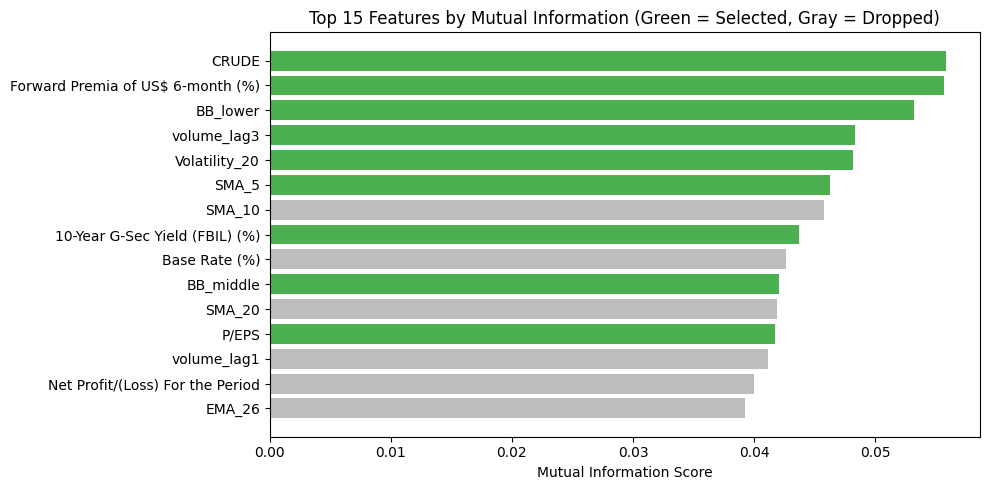


Interaction candidates (after adding back key domain features): ['Volume', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'SMA_5', 'MACD_signal', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'Volatility_20', 'log_return_lag5', 'volume_lag3', 'VWAP', 'Basic EPS']
Creating interactions from top 7: ['SMA_5', 'BB_lower', 'VWAP', 'volume_lag3', 'Volatility_20', 'BB_middle', 'BB_bandwidth']
✅ Added 21 interaction features
   Total features for modeling: 52
Before rolling standardization: (1420, 106)
✅ Rolling standardization complete. Final rows: 1410
Final usable data range:
2020-03-26 00:00:00 → 2025-12-30 00:00:00
Train shape: (1285, 52), Val shape: (64, 52), Test shape: (61, 52)
Train target distribution: target
1    0.529961
0    0.470039
Name: proportion, dtype: float64
Val target distribution: target
0    0.546875
1    0.453125
Name: proportion, dtype: float64
Test target distribution: target
1    0.52459
0    0.47541
Name: proportion, dtype: float64
T

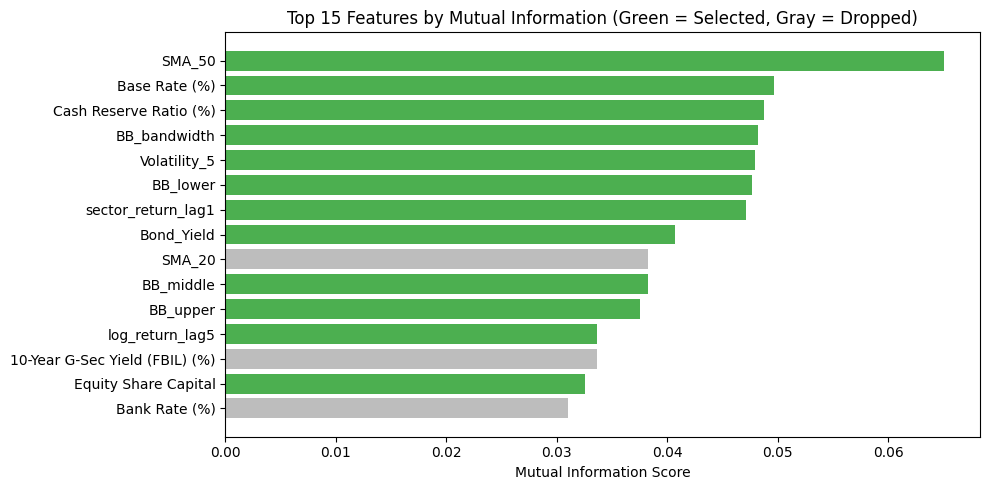


Interaction candidates (after adding back key domain features): ['Volume', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'SMA_50', 'RSI_14', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'Volatility_5', 'log_return_lag5', 'volume_lag2', 'VWAP', 'Basic EPS']
Creating interactions from top 7: ['SMA_50', 'Volatility_5', 'BB_lower', 'BB_upper', 'BB_bandwidth', 'BB_middle', 'sector_return_lag1']
✅ Added 21 interaction features
   Total features for modeling: 49
Before rolling standardization: (1420, 102)
✅ Rolling standardization complete. Final rows: 1410
Final usable data range:
2020-03-26 00:00:00 → 2025-12-30 00:00:00
Train shape: (1285, 49), Val shape: (64, 49), Test shape: (61, 49)
Train target distribution: target
1    0.525292
0    0.474708
Name: proportion, dtype: float64
Val target distribution: target
0    0.546875
1    0.453125
Name: proportion, dtype: float64
Test target distribution: target
1    0.52459
0    0.47541
Name: proportion, dtype: flo

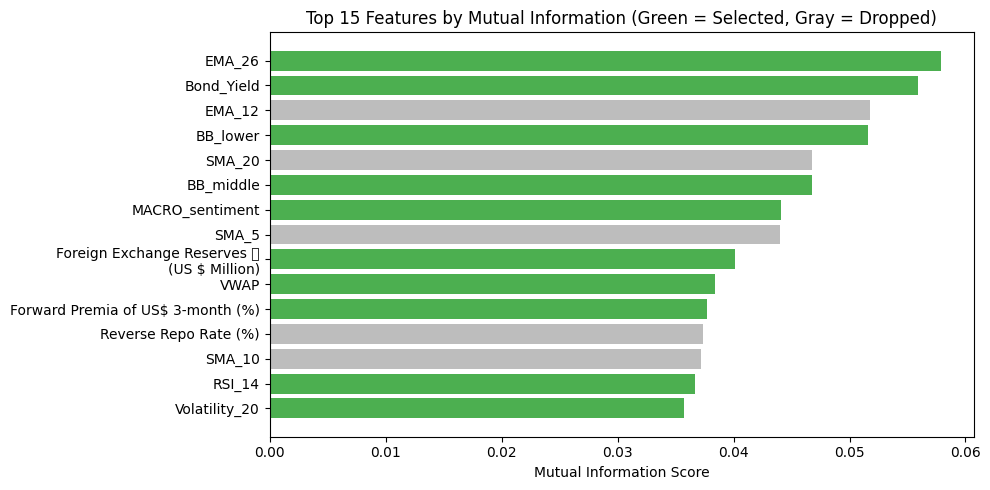


Interaction candidates (after adding back key domain features): ['Volume', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'EMA_26', 'RSI_14', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'Volatility_20', 'log_return_lag3', 'volume_lag2', 'VWAP', 'Basic EPS']
Creating interactions from top 7: ['EMA_26', 'Volatility_20', 'Foreign Exchange Reserves \r\n(US $ Million)', 'BB_middle', 'BB_lower', 'VWAP', 'BB_upper']
✅ Added 21 interaction features
   Total features for modeling: 49
Before rolling standardization: (1420, 106)
✅ Rolling standardization complete. Final rows: 1410
Final usable data range:
2020-03-26 00:00:00 → 2025-12-30 00:00:00
Train shape: (1285, 49), Val shape: (64, 49), Test shape: (61, 49)
Train target distribution: target
1    0.533852
0    0.466148
Name: proportion, dtype: float64
Val target distribution: target
0    0.515625
1    0.484375
Name: proportion, dtype: float64
Test target distrib

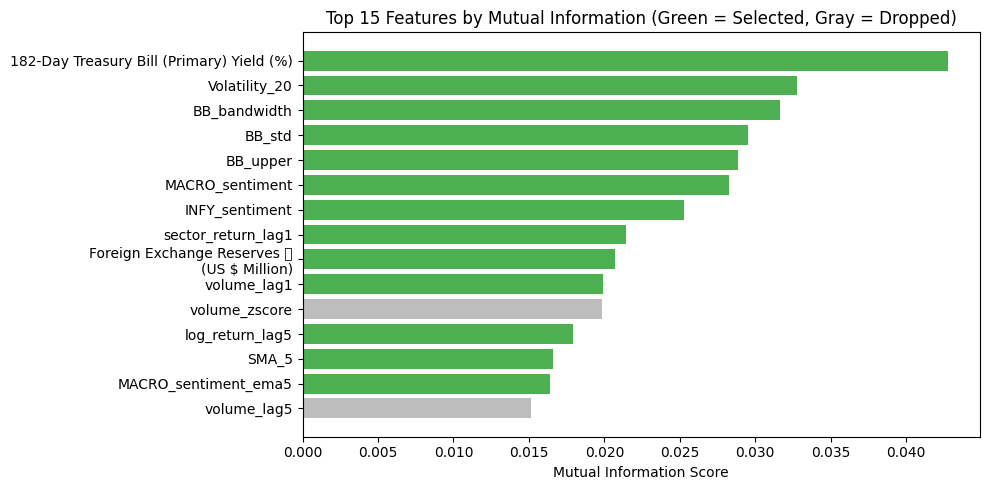


Interaction candidates (after adding back key domain features): ['Volume', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'SMA_5', 'MACD', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'Volatility_20', 'log_return_lag5', 'volume_lag1', 'VWAP', 'Basic EPS']
Creating interactions from top 7: ['BB_bandwidth', 'BB_std', 'volume_lag1', 'Volatility_20', 'sector_return_lag1', 'SMA_5', 'BB_upper']
✅ Added 21 interaction features
   Total features for modeling: 52
Before rolling standardization: (1420, 106)
✅ Rolling standardization complete. Final rows: 1410
Final usable data range:
2020-03-26 00:00:00 → 2025-12-30 00:00:00
Train shape: (1285, 52), Val shape: (64, 52), Test shape: (61, 52)
Train target distribution: target
1    0.525292
0    0.474708
Name: proportion, dtype: float64
Val target distribution: target
0    0.578125
1    0.421875
Name: proportion, dtype: float64
Test target distribution: target
1    0.5

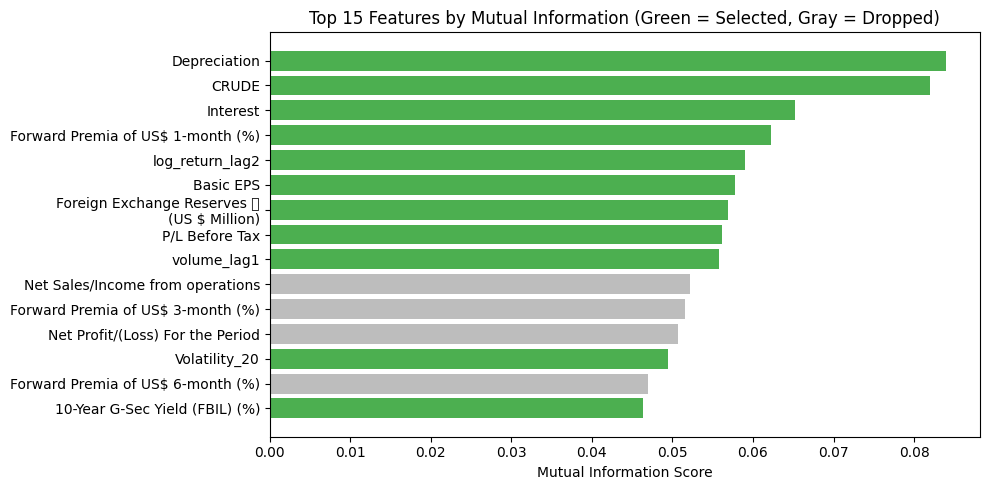


Interaction candidates (after adding back key domain features): ['Volume', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'SMA_20', 'RSI_14', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'Volatility_20', 'log_return_lag2', 'volume_lag1', 'VWAP', 'Basic EPS']
Creating interactions from top 7: ['Basic EPS', 'volume_lag1', 'log_return_lag2', 'Foreign Exchange Reserves \r\n(US $ Million)', 'BB_middle', 'SMA_20', 'Volatility_20']
✅ Added 21 interaction features
   Total features for modeling: 45
Before rolling standardization: (1420, 106)
✅ Rolling standardization complete. Final rows: 1410
Final usable data range:
2020-03-26 00:00:00 → 2025-12-30 00:00:00
Train shape: (1285, 45), Val shape: (64, 45), Test shape: (61, 45)
Train target distribution: target
0    0.509728
1    0.490272
Name: proportion, dtype: float64
Val target distribution: target
0    0.515625
1    0.484375
Name: proportion, dtype: float64
Test

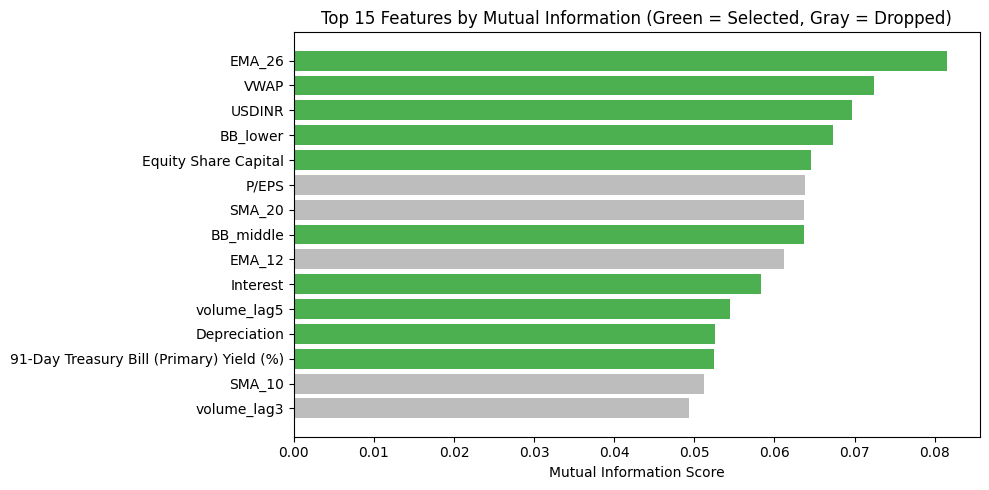


Interaction candidates (after adding back key domain features): ['Volume', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'EMA_26', 'MACD_signal', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_pct', 'Volatility_5', 'log_return_lag1', 'volume_lag5', 'VWAP', 'Basic EPS']
Creating interactions from top 7: ['BB_lower', 'EMA_26', 'VWAP', 'BB_middle', 'volume_lag5', 'BB_upper', 'Volume']
✅ Added 21 interaction features
   Total features for modeling: 52
Before rolling standardization: (1420, 106)
✅ Rolling standardization complete. Final rows: 1410
Final usable data range:
2020-03-26 00:00:00 → 2025-12-30 00:00:00
Train shape: (1285, 52), Val shape: (64, 52), Test shape: (61, 52)
Train target distribution: target
1    0.514397
0    0.485603
Name: proportion, dtype: float64
Val target distribution: target
0    0.5625
1    0.4375
Name: proportion, dtype: float64
Test target distribution: target
1    0.590164
0    0.409836
Name: proportion, dtype: float64
Train dates: 2020-0

In [29]:
stocks = {
    "RELIANCE": reliance_ml_data,
    "HDFC": HDFC_ml_data,
    "MM": MM_ml_data,
    "INFY": INFY_ml_data,
    "HUL": HUL_ml_data,
    "BHARTI": BHARTIARTL_ml_data
}

results_summary = []
returns_dict = {}
for name, data in stocks.items():

    prepared = prepare_stock_dataframe(data, name, target_type="raw")

    r2, acc, lgbm_reg, xgb_reg, lgbm_clf, X_test_model,y_test,y_test_bin = train_stock_model(prepared, name)

    results_summary.append({
        "Stock": name,
        "R2": r2,
        "Accuracy": acc
    })

    pred_returns = lgbm_reg.predict(X_test_model)

    test_dates = prepared[prepared["Date"] >= "2025-10-01"]["Date"].iloc[-len(pred_returns):]
    # Store predictions
    returns_dict[name] = pd.Series(pred_returns, index=test_dates)


results_df = pd.DataFrame(results_summary)
print("\nFINAL SUMMARY")
print(results_df)

In [30]:
# ============================================
# CREATE RETURNS MATRIX FROM ML PREDICTIONS
# ============================================

returns_df = pd.concat(returns_dict, axis=1)

# Ensure column names are clean
returns_df.columns = returns_df.columns.get_level_values(0)

# Sort by date just in case
returns_df.sort_index(inplace=True)

# Drop rows where any stock missing
returns_df.dropna(inplace=True)

print("Returns matrix shape:", returns_df.shape)
print("\nSample of predicted returns:")
print(returns_df.head())

Returns matrix shape: (61, 6)

Sample of predicted returns:
            RELIANCE      HDFC        MM      INFY       HUL    BHARTI
Date                                                                  
2025-10-01  0.000464  0.000456  0.000553  0.000829  0.001893  0.000624
2025-10-03 -0.000738 -0.000104  0.000751  0.000880  0.004447  0.000632
2025-10-06  0.000306 -0.000104  0.000751  0.000880  0.000196  0.001760
2025-10-07  0.000363  0.000360  0.002143  0.000880  0.001226  0.001102
2025-10-08  0.000727 -0.000852  0.001956  0.000880  0.000196  0.001585


In [33]:
# ============================================
# COMPUTE EXPECTED RETURNS & COVARIANCE
# ============================================

# Ensure no missing values remain
returns_df = returns_df.dropna()

# Annualized expected returns
mu = returns_df.mean() * 252

# Annualized covariance matrix
cov = returns_df.cov() * 252

print("\nAnnualized Expected Returns (μ):")
print(mu.sort_values(ascending=False))

print("\nCovariance Matrix (Σ):")
print(cov)

print("\nSanity Check:")
print("Avg daily return:", returns_df.mean().mean())
print("Avg daily volatility:", returns_df.std().mean())


Annualized Expected Returns (μ):
MM          0.421066
BHARTI      0.331727
HUL         0.285440
INFY        0.232135
HDFC        0.192913
RELIANCE    0.120465
dtype: float64

Covariance Matrix (Σ):
              RELIANCE          HDFC        MM          INFY       HUL  \
RELIANCE  2.387378e-04  9.996798e-07  0.000001 -3.059710e-06 -0.000186   
HDFC      9.996798e-07  9.108395e-05  0.000033 -8.574966e-07  0.000038   
MM        1.454935e-06  3.311889e-05  0.000239 -8.725459e-06  0.000045   
INFY     -3.059710e-06 -8.574966e-07 -0.000009  6.290793e-06  0.000017   
HUL      -1.856753e-04  3.765335e-05  0.000045  1.732458e-05  0.000890   
BHARTI   -1.581904e-05  4.614802e-06  0.000008  2.492231e-06 -0.000037   

            BHARTI  
RELIANCE -0.000016  
HDFC      0.000005  
MM        0.000008  
INFY      0.000002  
HUL      -0.000037  
BHARTI    0.000115  

Sanity Check:
Avg daily return: 0.001047451970981173
Avg daily volatility: 0.000877046458963521


In [34]:
# ============================================
# MONTE CARLO EFFICIENT FRONTIER
# ============================================

import numpy as np

num_portfolios = 50000
num_assets = len(mu)

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):

    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    weights_record.append(weights)

    port_return = np.dot(weights, mu)
    port_risk = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    rf = 0.06   # example: 6% Indian risk-free rate

    sharpe = (port_return - rf) / port_risk

    results[0, i] = port_return
    results[1, i] = port_risk
    results[2, i] = sharpe

In [35]:
# ============================================
# FIND MAX SHARPE & GMV
# ============================================

max_sharpe_idx = np.argmax(results[2])
gmv_idx = np.argmin(results[1])

max_sharpe_weights = weights_record[max_sharpe_idx]
gmv_weights = weights_record[gmv_idx]

max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_risk = results[1, max_sharpe_idx]

gmv_return = results[0, gmv_idx]
gmv_risk = results[1, gmv_idx]

In [36]:
# ============================================
# SHOW PORTFOLIO WEIGHTS
# ============================================

max_sharpe_df = pd.DataFrame({
    "Stock": mu.index,
    "Weight": max_sharpe_weights
}).sort_values("Weight", ascending=False)

gmv_df = pd.DataFrame({
    "Stock": mu.index,
    "Weight": gmv_weights
}).sort_values("Weight", ascending=False)

print("\n==============================")
print("MAX SHARPE PORTFOLIO")
print("==============================")
print(max_sharpe_df)

print("\n==============================")
print("GLOBAL MINIMUM VARIANCE")
print("==============================")
print(gmv_df)


MAX SHARPE PORTFOLIO
      Stock    Weight
3      INFY  0.669050
2        MM  0.106924
5    BHARTI  0.082135
1      HDFC  0.061534
0  RELIANCE  0.058751
4       HUL  0.021605

GLOBAL MINIMUM VARIANCE
      Stock    Weight
3      INFY  0.712494
0  RELIANCE  0.117206
5    BHARTI  0.100089
1      HDFC  0.053758
4       HUL  0.014960
2        MM  0.001492


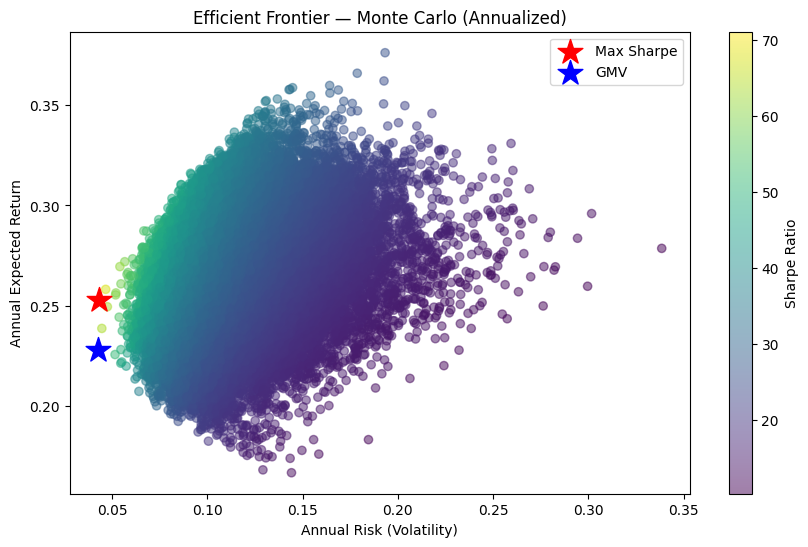

Max Sharpe Portfolio:
Return = 0.2527 Risk = 0.0027
Weights: {'RELIANCE': np.float64(0.05875125388586685), 'HDFC': np.float64(0.06153371833496119), 'MM': np.float64(0.10692437052033496), 'INFY': np.float64(0.6690501274317491), 'HUL': np.float64(0.021605203701918086), 'BHARTI': np.float64(0.08213532612516983)}

GMV Portfolio:
Return = 0.228 Risk = 0.0027
Weights: {'RELIANCE': np.float64(0.1172062890772662), 'HDFC': np.float64(0.05375809299479665), 'MM': np.float64(0.0014923067127792314), 'INFY': np.float64(0.7124939645155253), 'HUL': np.float64(0.014960114049679094), 'BHARTI': np.float64(0.10008923264995342)}


In [37]:
# ============================================
# PLOT ANNUALIZED EFFICIENT FRONTIER
# ============================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# Convert daily risk → annual risk
annual_risk = results[1, :] * np.sqrt(252)

# Plot frontier
plt.scatter(annual_risk, results[0, :],
            c=results[2, :], cmap="viridis", alpha=0.5)

plt.colorbar(label="Sharpe Ratio")

# Highlight optimal portfolios
plt.scatter(annual_risk[max_sharpe_idx],
            results[0, max_sharpe_idx],
            marker="*", s=350, color="red", label="Max Sharpe")

plt.scatter(annual_risk[gmv_idx],
            results[0, gmv_idx],
            marker="*", s=350, color="blue", label="GMV")

plt.xlabel("Annual Risk (Volatility)")
plt.ylabel("Annual Expected Return")
plt.title("Efficient Frontier — Monte Carlo (Annualized)")
plt.legend()
plt.show()

print("Max Sharpe Portfolio:")
print("Return =", round(max_sharpe_return,4), "Risk =", round(max_sharpe_risk,4))
print("Weights:", dict(zip(mu.index, max_sharpe_weights)))

print("\nGMV Portfolio:")
print("Return =", round(gmv_return,4), "Risk =", round(gmv_risk,4))
print("Weights:", dict(zip(mu.index, gmv_weights)))

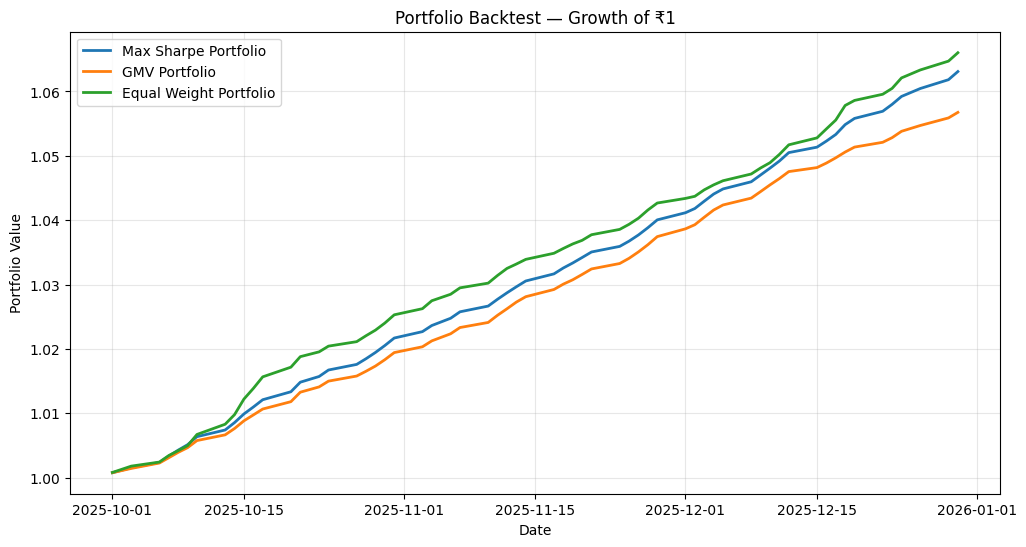

In [38]:
# ============================================
# CONVERT LOG RETURNS → SIMPLE RETURNS
# ============================================

simple_returns = np.exp(returns_df) - 1

# ============================================
# CONVERT LOG RETURNS → SIMPLE RETURNS
# ============================================

simple_returns = np.exp(returns_df) - 1

# ============================================
# CREATE PORTFOLIO DAILY RETURNS
# ============================================

# Convert weights to numpy arrays
w_max = np.array(max_sharpe_weights)
w_gmv = np.array(gmv_weights)

# Equal weight portfolio
w_equal = np.ones(len(mu)) / len(mu)

# Compute daily portfolio returns
max_sharpe_port = simple_returns @ w_max
gmv_port = simple_returns @ w_gmv
equal_port = simple_returns @ w_equal

# ============================================
# CUMULATIVE RETURNS
# ============================================

max_sharpe_cum = (1 + max_sharpe_port).cumprod()
gmv_cum = (1 + gmv_port).cumprod()
equal_cum = (1 + equal_port).cumprod()

# ============================================
# PLOT BACKTEST PERFORMANCE
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(max_sharpe_cum, label="Max Sharpe Portfolio", linewidth=2)
plt.plot(gmv_cum, label="GMV Portfolio", linewidth=2)
plt.plot(equal_cum, label="Equal Weight Portfolio", linewidth=2)

plt.title("Portfolio Backtest — Growth of ₹1")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [31]:
#walforward version
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, RobustScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import r2_score, accuracy_score
from lightgbm import LGBMRegressor, LGBMClassifier
from xgboost import XGBRegressor, XGBClassifier
import lightgbm as lgb
from feature_engine.outliers import Winsorizer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
ROLL_WINDOW = 30




# ============================================================
# DATA PREPARATION (YOUR ORIGINAL + RESIDUAL TARGET OPTION)
# ============================================================

def prepare_stock_dataframe(df, name, target_type="residual"):

    print(f"\nPreparing data for {name}...")
    df = df.copy()

    # 1️⃣ Date formatting
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    df.drop(columns=["QuarterDate", "Period",
                     "Standing Deposit Facility (SDF) Rate (%)"],
            inplace=True, errors="ignore")

    if "Depreciation" in df.columns and name == "HDFC":
        df.drop(columns=["Depreciation"], inplace=True, errors="ignore")

    # 2️⃣ Clean numeric columns
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].str.replace(",", "", regex=False)
            df[col] = df[col].replace(["-", "--", ""], np.nan)
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    sentiment_cols = [c for c in df.columns if "sentiment" in c.lower()]

    for col in sentiment_cols:
        df[f"{col}_ema5"] = df[col].ewm(span=5, adjust=False).mean()
        df[f"{col}_ema10"] = df[col].ewm(span=10, adjust=False).mean()
    

    # 3️⃣ Returns
    df["log_return"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
    df["sector_return"] = np.log(df["Sector_Close"] / df["Sector_Close"].shift(1))

    df["return_pct"] = df["Adj Close"] / df["Adj Close"].shift(1) - 1
    df["sector_return_pct"] = df["Sector_Close"]/df["Sector_Close"].shift(1) - 1

    if target_type == "residual":
        df["target"] = (df["return_pct"] - df["sector_return_pct"]).shift(-1)
    else:
        df["target"] = df["log_return"].shift(-1)


    # 4️⃣ Lag macro & sentiment to remove look-ahead bias doing this in data prep instead of feature engineering to ensure all features are aligned and no leakage
    macro_cols = [
        "USDINR", "USDINR_ret", "CRUDE_ret", "CRUDE", "Bond_Yield", "Period",
        "Forward Premia of US$ 1-month (%)", "Forward Premia of US$ 3-month (%)",
        "Forward Premia of US$ 6-month (%)", "Reverse Repo Rate (%)",
        "Marginal Standing Facility (MSF) Rate (%)", "Bank Rate (%)",
        "Base Rate (%)", "91-Day Treasury Bill (Primary) Yield (%)",
        "182-Day Treasury Bill (Primary) Yield (%)",
        "364-Day Treasury Bill (Primary) Yield (%)",
        "10-Year G-Sec Yield (FBIL) (%)", "Cash Reserve Ratio (%)",
        "Statutory Liquidity Ratio (%)", "Policy Repo Rate (%)",
        "Standing Deposit Facility (SDF) Rate (%)",
        '"Foreign Exchange Reserves \n(US $ Million)"', 'MACRO_sentiment'
    ]

    # ============================================================
    # 5️⃣ ADVANCED TECHNICAL INDICATORS
    # ============================================================

    eps = 1e-9  # avoid divide-by-zero

    #add sector return also as an indicator for prediction
    df["sector_return"] = np.log(df["Sector_Close"] / df["Sector_Close"].shift(1))
    df["sector_return_lag1"] = df["sector_return"].shift(1)

    # ----- Buying & Selling Pressure -----
    df["Buying_Pressure"]  = (df["Close"] - df["Low"]) / (df["High"] - df["Low"] + eps)
    df["Selling_Pressure"] = (df["High"] - df["Close"]) / (df["High"] - df["Low"] + eps)

    # ----- Simple Moving Averages -----
    for window in [5, 10, 20, 50]:
        df[f"SMA_{window}"] = df["Adj Close"].rolling(window).mean()

    # ----- Exponential Moving Averages -----
    df["EMA_12"] = df["Adj Close"].ewm(span=12, adjust=False).mean()
    df["EMA_26"] = df["Adj Close"].ewm(span=26, adjust=False).mean()

    # ----- MACD -----
    df["MACD"] = df["EMA_12"] - df["EMA_26"]
    df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

    # ----- RSI (14-day) -----
    delta = df["Adj Close"].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + eps)
    df["RSI_14"] = 100 - (100 / (1 + rs))

    # ----- Bollinger Bands -----
    df["BB_middle"] = df["Adj Close"].rolling(20).mean()
    df["BB_std"] = df["Adj Close"].rolling(20).std()
    df["BB_upper"] = df["BB_middle"] + 2 * df["BB_std"]
    df["BB_lower"] = df["BB_middle"] - 2 * df["BB_std"]

    df["BB_bandwidth"] = (df["BB_upper"] - df["BB_lower"]) / (df["BB_middle"] + eps)
    df["BB_pct"] = (df["Adj Close"] - df["BB_lower"]) / (df["BB_upper"] - df["BB_lower"] + eps)

    # ----- Volatility -----
    df["Volatility_5"] = df["log_return"].rolling(5).std()
    df["Volatility_20"] = df["log_return"].rolling(20).std()

    # ----- Lagged Returns -----
    for lag in [1, 2, 3, 5]:
        df[f"log_return_lag{lag}"] = df["log_return"].shift(lag)

    # ----- Lagged Volume -----
    for lag in [1, 2, 3, 5]:
        df[f"volume_lag{lag}"] = df["Volume"].shift(lag)
    #volume z score
    df["volume_zscore"] = (df["Volume"] - df["Volume"].rolling(20).mean()) / (df["Volume"].rolling(20).std() + eps)

    #add vwap as a feature
    df["VWAP"] = (df["Volume"] * df["Adj Close"]).rolling(20).sum() / df["Volume"].rolling(20).sum()

    print(f"Technical features created. Total columns: {len(df.columns)}")

    # Drop NaNs
    df = df.dropna().reset_index(drop=True)
    print(f"Data after dropping NaNs: {df.shape}")

    return df


# ============================================================
# MODEL TRAINING (YOUR STRUCTURE + SAFE ADDITIONS)
# ============================================================

def train_stock_model(df, stock_name):

    df = df.copy()


    

    exclude = ["target","log_return","sector_return",
               "Adj Close","Close","High","Low","Open","Sector_Close","Date", "return_pct", "sector_return_pct"]
    macro_cols = [
        "USDINR", "USDINR_ret", "CRUDE_ret", "CRUDE", "Bond_Yield", "Period",
        "Forward Premia of US$ 1-month (%)", "Forward Premia of US$ 3-month (%)",
        "Forward Premia of US$ 6-month (%)", "Reverse Repo Rate (%)",
        "Marginal Standing Facility (MSF) Rate (%)", "Bank Rate (%)",
        "Base Rate (%)", "91-Day Treasury Bill (Primary) Yield (%)",
        "182-Day Treasury Bill (Primary) Yield (%)",
        "364-Day Treasury Bill (Primary) Yield (%)",
        "10-Year G-Sec Yield (FBIL) (%)", "Cash Reserve Ratio (%)",
        "Statutory Liquidity Ratio (%)", "Policy Repo Rate (%)",
        "Standing Deposit Facility (SDF) Rate (%)",
        '"Foreign Exchange Reserves \r\n(US $ Million)"', 'MACRO_sentiment'
    ]
    
    fundamental_cols = ["Net Sales", "Income from operations", "Total Income From Operations", "Depreciation", "Interest", "P/L Before Tax", "Net Profit/(Loss) For the Period", "Equity Share Capital", "Basic EPS", "P/EPS"]
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    sentiment_cols = [c for c in df.columns if "sentiment" in c.lower()]

    candidate_features = [c for c in numeric_cols if c not in exclude and c not in fundamental_cols and c not in sentiment_cols]
    print(f"Initial features: {candidate_features}" )

    print(f"Total numeric columns: {len(numeric_cols)}, Candidate features: {len(candidate_features)}")

    nan_pct = df.isnull().sum() / len(df) * 100
    cols_to_drop = nan_pct[nan_pct > 15].index.tolist()
    if cols_to_drop:
        print(f'Dropping columns with >15% NaN: {cols_to_drop}')
        df = df.drop(columns=cols_to_drop)
        candidate_features = [c for c in candidate_features if c not in cols_to_drop]

    # Drop remaining NaN rows (from technical indicator warm-up)
    rows_before = len(df)
    df_clean = df.dropna()
    print(f'Dropped {rows_before - len(df_clean)} rows (technical warm-up period)')
    print(f'Remaining: {len(df_clean)} rows')

    # --------------------------
    # WINSORIZATION (train only bounds)
    # --------------------------
    existing_candidate_features = [f for f in candidate_features if f in df_clean.columns]

    winsorizer = Winsorizer(capping_method='quantiles', tail='both', fold=0.01, variables=existing_candidate_features)
    df_wins = winsorizer.fit_transform(df_clean)
    print(f'\n✅ Winsorization applied to {len(existing_candidate_features)} features (1st–99th pctile)')
    # --------------------------
    # MUTUAL INFORMATION SELECTION
    # --------------------------

    all_feature_cols = existing_candidate_features + [c for c in fundamental_cols if c in df_wins.columns] + sentiment_cols
    X_all = df_wins[all_feature_cols].copy()
    y = df_wins["target"].copy()

    X_all_train_temp = X_all[df_wins["Date"] < "2025-07-01"]
    y_train_temp = y[df_wins["Date"] < "2025-07-01"]

    mi_scores = mutual_info_regression(X_all_train_temp, y_train_temp, random_state=RANDOM_STATE)
    mi_series = pd.Series(mi_scores, index=all_feature_cols).sort_values(ascending=False)
    
    DOMAIN_GRPS = {

    # ------------------ MACRO BLOCK ------------------

    "Rates_Level": [
        "Bank Rate (%)",
        "Base Rate (%)",
        "Policy Repo Rate (%)",
        "Reverse Repo Rate (%)",
        "Marginal Standing Facility (MSF) Rate (%)",
        "Forward Premia of US$ 1-month (%)",
        "Forward Premia of US$ 3-month (%)",
        "Forward Premia of US$ 6-month (%)"
        
    ],

    "Rates_Curve": [
        "91-Day Treasury Bill (Primary) Yield (%)",
        "182-Day Treasury Bill (Primary) Yield (%)",
        "364-Day Treasury Bill (Primary) Yield (%)",
        "10-Year G-Sec Yield (FBIL) (%)",
        "Bond_Yield"
    ],

    "Liquidity": [
        "Cash Reserve Ratio (%)",
        "Statutory Liquidity Ratio (%)",
        "Foreign Exchange Reserves \r\n(US $ Million)"
    ],

    "Currency": [
        "USDINR",
        "USDINR_ret"
    ],

    "Commodities": [
        "CRUDE",
        "CRUDE_ret"
    ],

    # ------------------ TECHNICAL BLOCK ------------------

    "Momentum": [
        "MACD",
        "RSI_14"
    ],

    "Moving_Averages": [
        "SMA_5", "SMA_10", "SMA_20", "SMA_50",
        "EMA_12", "EMA_26"
    ],

    "Volatility": [
        "Volatility_5",
        "Volatility_20"
    ],

    "Bollinger": [
        "BB_bandwidth",
        "BB_pct"
    ],

    "Returns_Lags": [
        "log_return_lag1",
        "log_return_lag2",
        "log_return_lag3",
        "log_return_lag5"
    ],

    "Volume": [
        "volume_lag1",
        "volume_lag2",
        "volume_lag3",
        "volume_lag5",
        "volume_zscore"
    ],

    # ------------------ FUNDAMENTALS ------------------

    "Fundamentals": [
        "Basic EPS",
        "P/EPS",
        "Net Profit/(Loss) For the Period",
        "Equity Share Capital",
        "Net Sales/Income from operations"
    ]
}


    # For each group: keep best, drop rest
    features_to_drop = set()
    print('Domain-Based Feature Selection Results:')
    print('=' * 70)
    for domain, keywords in DOMAIN_GRPS.items():
        if domain in ['Fundamentals']:
            group = [f for f in keywords if f in X_all.columns]
        else:
            group = [f for f in X_all.columns if any(k in f for k in keywords)]

        if len(group) <= 1:
            continue

        winner = mi_series[group].idxmax()
        losers = set(group) - {winner}
        features_to_drop.update(losers)
        print(f'  {domain:<18} → Winner: {winner:<22} (MI={mi_series[winner]:.4f}) | Dropped: {len(losers)} others')

    SELECTED = [c for c in X_all.columns if c not in features_to_drop]
    #add sentiment cols if not already included
    for s_col in sentiment_cols:
        if s_col not in SELECTED and s_col in X_all.columns:
            SELECTED.append(s_col)

    print(f'\n✅ Selected {len(SELECTED)} features (from {len(X_all.columns)} candidates)')
    print(f'   Features: {SELECTED}')

    top_mi  = mi_series.head(15)
    plt.figure(figsize=(10, 5))
    colors = ['#4CAF50' if f in SELECTED else '#BDBDBD' for f in top_mi.index]
    plt.barh(range(len(top_mi)), top_mi.values, color=colors)
    plt.yticks(range(len(top_mi)), top_mi.index)
    plt.xlabel('Mutual Information Score')
    plt.title('Top 15 Features by Mutual Information (Green = Selected, Gray = Dropped)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    #remove macro and sentiment cols from interaction candidates
    interaction_candidates = [f for f in SELECTED if f not in fundamental_cols and f not in sentiment_cols and f not in macro_cols]
    #add USDINR, CRUDE, Basic EPS ,Bond Yield back to interaction candidates even if they were not selected in the main effects because they are important domain features and may have strong interactions

    interaction_candidates += [f for f in [ "Basic EPS"] if f in X_all.columns and f not in interaction_candidates]
    print(f'\nInteraction candidates (after adding back key domain features): {interaction_candidates}')

    # ============================================================
    # INTERACTION FEATURES
    # ============================================================
    # Pick top 6 features by MI for interactions
    mi_selected = mutual_info_regression(df_wins[interaction_candidates].fillna(0), y, random_state=RANDOM_STATE)
    top_6 = pd.Series(mi_selected, index=interaction_candidates).nlargest(6).index.tolist()
    print(f'Creating interactions from top 6: {top_6}')

    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

    inter_matrix = poly.fit_transform(df_wins[top_6])

    raw_names = poly.get_feature_names_out(top_6)

    # Rename properly
    clean_names = []
    for name in raw_names:
        if " " in name:   # this is an interaction term
            parts = name.split(" ")
            clean_names.append(f"{parts[0]}_x_{parts[1]}")
        else:
            clean_names.append(name)  # original feature

    inter_df = pd.DataFrame(inter_matrix, columns=clean_names, index=df_wins.index)

    df_final = pd.concat([df_wins, inter_df], axis=1)
    ALL_FEATS = list(dict.fromkeys(SELECTED +list(clean_names)))  # Deduplicate

    print(f'✅ Added {len(clean_names) - len(top_6)} interaction features')
    print(f'   Total features for modeling: {len(ALL_FEATS)}')

    # ============================================================
    # ROLLING STANDARDIZATION (30-day lookback)
    # ============================================================
    ROLLING_WINDOW = 30
    df_scaled = df_final.copy()

    #print shapes to verify
    print(f"Before rolling standardization: {df_scaled.shape}")

    for col in ALL_FEATS:
        if col not in df_final.columns:
            continue
        # Skip fundamentals (they're step functions — rolling std would be 0)
        if col in fundamental_cols or col in sentiment_cols:
            continue

        # Use shift(1) so we only use PAST data (no peeking at today)
        roll_mean = df_final[col].shift(1).rolling(ROLLING_WINDOW, min_periods=10).mean()
        roll_std  = df_final[col].shift(1).rolling(ROLLING_WINDOW, min_periods=10).std() + 1e-9  # avoid divide-by-zero
        df_scaled[col] = (df_final[col] - roll_mean) / roll_std.replace(0, np.nan)

    # Drop rows with NaN from rolling warm-up
    df_scaled = df_scaled.dropna(subset=ALL_FEATS + ['target']).reset_index(drop=True)
    df_scaled = df_scaled.loc[:, ~df_scaled.columns.duplicated()]  # Remove duplicate columns

    print(f'✅ Rolling standardization complete. Final rows: {len(df_scaled)}')

    print("Final usable data range:")
    print(df_scaled["Date"].min(), "→", df_scaled["Date"].max())

    # X_train = df_scaled[df_scaled["Date"] < "2025-07-01"][ALL_FEATS]
    # y_train = df_scaled[df_scaled["Date"] < "2025-07-01"]["target"]
    # X_val   = df_scaled[(df_scaled["Date"] >= "2025-07-01") & (df_scaled["Date"] < "2025-10-01")][ALL_FEATS]
    # y_val   = df_scaled[(df_scaled["Date"] >= "2025-07-01") & (df_scaled["Date"] < "2025-10-01")]["target"]
    # X_test  = df_scaled[df_scaled["Date"] >= "2025-10-01"][ALL_FEATS]
    # y_test  = df_scaled[df_scaled["Date"] >= "2025-10-01"]["target"]
    # y_train_bin = (y_train > 0).astype(int)
    # y_val_bin   = (y_val > 0).astype(int)
    # y_test_bin  = (y_test > 0).astype(int)

    # #print shapes to verify
    # print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")
    # print(f"Train target distribution: {y_train_bin.value_counts(normalize=True)}")
    # print(f"Val target distribution: {y_val_bin.value_counts(normalize=True)}")
    # print(f"Test target distribution: {y_test_bin.value_counts(normalize=True)}")
    # #print dates
    # print(f"Train dates: {df_scaled[df_scaled['Date'] < '2025-07-01']['Date'].min()} to {df_scaled[df_scaled['Date'] < '2025-07-01']['Date'].max()}")
    # print(f"Val dates: {df_scaled[(df_scaled['Date'] >= '2025-07-01') & (df_scaled['Date'] < '2025-10-01')]['Date'].min()} to {df_scaled[(df_scaled['Date'] >= '2025-07-01') & (df_scaled['Date'] < '2025-10-01')]['Date'].max()}")
    # print(f"Test dates: {df_scaled[df_scaled['Date'] >= '2025-10-01']['Date'].min()} to {df_scaled[df_scaled['Date'] >= '2025-10-01']['Date'].max()}")


    # print(f"X_train columns: {list(X_train.columns)}")
    # print(f"X_val columns: {list(X_val.columns)}")
    # if list(X_train.columns) != list(X_val.columns):
    #     print("❌ Column mismatch between train and val sets!")
    #     missing_in_val = set(X_train.columns) - set(X_val.columns)
    #     missing_in_train = set(X_val.columns) - set(X_train.columns)
    #     print(f"Missing in val: {missing_in_val}")
    #     print(f"Missing in train: {missing_in_train}")

    # # ============================================================
    # # MODEL TRAINING
    # # ============================================================
    # # -------------------------------------------------
    # # CLEAN FEATURE NAMES ONLY FOR MODEL INPUT
    # # -------------------------------------------------

    # def clean_feature_names(columns):
    #     return (
    #         pd.Index(columns)
    #         .str.replace(r"\s+", "_", regex=True)
    #         .str.replace(r"[^\w_]", "", regex=True)
    #     )

    # # Make copies so original X_train remains untouched
    # X_train_model = X_train.copy()
    # X_val_model   = X_val.copy()
    # X_test_model  = X_test.copy()

    # clean_cols = clean_feature_names(X_train_model.columns)

    # X_train_model.columns = clean_cols
    # X_val_model.columns   = clean_cols
    # X_test_model.columns  = clean_cols

    # # -------------------------------------------------
    # # TRAIN LIGHTGBM
    # # -------------------------------------------------
    # # --- 1. LightGBM Regressor ---
    # print('🔍 Training LightGBM Regressor...')
    
    

    # lgbm_reg = LGBMRegressor(
    #     n_estimators=1000, learning_rate=0.03, max_depth=5,
    #     random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    # )
    # lgbm_reg.fit(
    #     X_train_model, y_train,
    #     eval_set=[(X_val_model, y_val)],
    #     callbacks=[lgb.early_stopping(50, verbose=False)]
    # )
    # # --- 2. XGBoost Regressor ---
    # print('🔍 Training XGBoost Regressor...')
    # xgb_reg = XGBRegressor(
    #     n_estimators=1000, learning_rate=0.03, max_depth=5,
    #     random_state=RANDOM_STATE, n_jobs=-1, early_stopping_rounds=50, verbosity=0
    # )
    # xgb_reg.fit(X_train_model, y_train,
    #         eval_set=[(X_val_model, y_val)],
    #         verbose=False)
    # # --- 3. LightGBM Classifier ---
    # print('🔍 Training LightGBM Classifier...')
    # lgbm_clf = LGBMClassifier(
    #     n_estimators=1000, learning_rate=0.03, max_depth=5,
    #     random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    # )
    # lgbm_clf.fit(X_train_model, y_train_bin,
    #             eval_set=[(X_val_model, y_val_bin)],
    #             callbacks=[lgb.early_stopping(50, verbose=False)])

    # print('\n🏆 All 3 models trained!')

    # # ============================================================
    # # PREDICTIONS & METRICS
    # # ============================================================
    # pred_lgbm = lgbm_reg.predict(X_test_model)
    # pred_xgb  = xgb_reg.predict(X_test_model)
    # pred_cls  = lgbm_clf.predict(X_test_model)
    # pred_prob = lgbm_clf.predict_proba(X_test_model)[:, 1]  # Probability of "Up"

    # # High-Confidence filtering: only keep top 20% most confident predictions
    # confidence = np.abs(pred_prob - 0.5)  # Distance from 0.5 = uncertainty
    # threshold = np.percentile(confidence, 80)
    # high_conf_mask = confidence >= threshold

    # # Calculate metrics
    # r2_lgbm = r2_score(y_test, pred_lgbm)
    # r2_xgb  = r2_score(y_test, pred_xgb)
    # acc_all  = accuracy_score(y_test_bin, pred_cls)
    # acc_high = accuracy_score(y_test_bin[high_conf_mask], pred_cls[high_conf_mask])

    # print('╔' + '═'*48 + '╗')
    # print('║     FINAL RESULTS (Out-of-Sample Test Set)     ║')
    # print('╠' + '═'*48 + '╣')
    # print(f'║  LightGBM Regressor R²    :  {r2_lgbm:>8.4f}          ║')
    # print(f'║  XGBoost  Regressor R²    :  {r2_xgb:>8.4f}          ║')
    # print(f'║  Classifier Accuracy      :  {acc_all*100:>6.1f}%           ║')
    # print(f'║  High-Confidence Accuracy :  {acc_high*100:>6.1f}% (Top 20%) ║')
    # print('╚' + '═'*48 + '╝')

    # return r2_lgbm, acc_high, lgbm_reg, xgb_reg, lgbm_clf, X_test_model, y_test, y_test_bin
    # ============================================================
    # TIME SERIES CROSS VALIDATION (EXPANDING WINDOW)
    # ============================================================

    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.metrics import mean_squared_error

    df_scaled = df_scaled.sort_values("Date").reset_index(drop=True)

    X_all = df_scaled[ALL_FEATS].copy()
    y_all = df_scaled["target"].copy()

    # Clean feature names ONCE
    def clean_feature_names(columns):
        return (
            pd.Index(columns)
            .str.replace(r"\s+", "_", regex=True)
            .str.replace(r"[^\w_]", "", regex=True)
        )

    clean_cols = clean_feature_names(X_all.columns)
    X_all.columns = clean_cols

    tscv = TimeSeriesSplit(n_splits=5, test_size=252)

    cv_r2 = []
    cv_rmse = []
    cv_acc = []

    print("\n================ TIME SERIES CV ================\n")

    fold = 1
    for train_idx, val_idx in tscv.split(X_all):

        X_train, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
        y_train, y_val = y_all.iloc[train_idx], y_all.iloc[val_idx]

        train_data = lgb.Dataset(X_train, label=y_train)
        valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

        params = {
            'objective': 'regression',
            'metric': 'rmse',
            'learning_rate': 0.03,
            'verbosity': -1,
            'seed': RANDOM_STATE
        }

        model = lgb.train(
            params,
            train_data,
            num_boost_round=1000,
            valid_sets=[valid_data],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        preds = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        r2 = r2_score(y_val, preds)

        preds_bin = (preds > 0).astype(int)
        y_val_bin = (y_val > 0).astype(int)
        acc = accuracy_score(y_val_bin, preds_bin)

        cv_rmse.append(rmse)
        cv_r2.append(r2)
        cv_acc.append(acc)

        print(f"Fold {fold} | RMSE: {rmse:.6f} | R²: {r2:.4f} | Accuracy: {acc:.4f}")
        fold += 1

    print("\nCV Mean RMSE:", np.mean(cv_rmse))
    print("CV Mean R²:", np.mean(cv_r2))
    print("CV Mean Accuracy:", np.mean(cv_acc))


    # ============================================================
    # FINAL OUT-OF-SAMPLE TEST (OCT–DEC 2025)
    # ============================================================

    print("\n================ FINAL FORWARD TEST ================\n")

    train_mask = df_scaled["Date"] < "2025-10-01"
    test_mask  = df_scaled["Date"] >= "2025-10-01"

    X_train = X_all[train_mask]
    y_train = y_all[train_mask]

    X_test  = X_all[test_mask]
    y_test  = y_all[test_mask]

    final_train_data = lgb.Dataset(X_train, label=y_train)

    final_model = lgb.train(
        params,
        final_train_data,
        num_boost_round=int(np.mean([model.best_iteration]))
    )

    pred_test = final_model.predict(X_test)

    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    test_r2 = r2_score(y_test, pred_test)

    pred_test_bin = (pred_test > 0).astype(int)
    y_test_bin = (y_test > 0).astype(int)
    test_acc = accuracy_score(y_test_bin, pred_test_bin)

    print("Final Test RMSE:", test_rmse)
    print("Final Test R²:", test_r2)
    print("Final Test Accuracy:", test_acc)

    return test_r2, test_acc, final_model, X_test, y_test, y_test_bin


Preparing data for RELIANCE...
Technical features created. Total columns: 78
Data after dropping NaNs: (1420, 78)
Initial features: ['Volume', 'Net Sales/Income from operations', 'USDINR', 'USDINR_ret', 'CRUDE_ret', 'CRUDE', 'Bond_Yield', 'Forward Premia of US$ 1-month (%)', 'Forward Premia of US$ 3-month (%)', 'Forward Premia of US$ 6-month (%)', 'Reverse Repo Rate (%)', 'Marginal Standing Facility (MSF) Rate (%)', 'Bank Rate (%)', 'Base Rate (%)', '91-Day Treasury Bill (Primary) Yield (%)', '182-Day Treasury Bill (Primary) Yield (%)', '364-Day Treasury Bill (Primary) Yield (%)', '10-Year G-Sec Yield (FBIL) (%)', 'Cash Reserve Ratio (%)', 'Statutory Liquidity Ratio (%)', 'Policy Repo Rate (%)', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_signal', 'RSI_14', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'BB_pct', 'Volatility_5', 'Vol

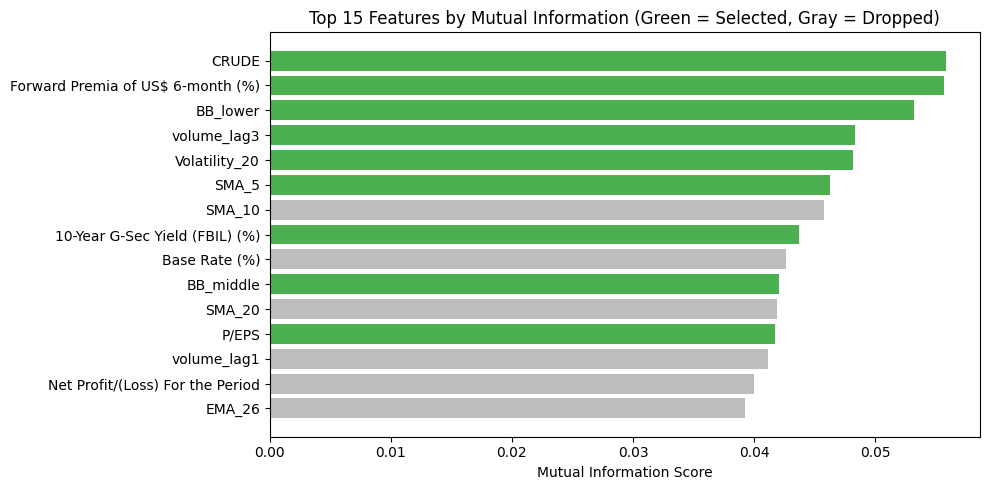


Interaction candidates (after adding back key domain features): ['Volume', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'SMA_5', 'MACD_signal', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'Volatility_20', 'log_return_lag5', 'volume_lag3', 'VWAP', 'Basic EPS']
Creating interactions from top 6: ['SMA_5', 'BB_lower', 'VWAP', 'volume_lag3', 'Volatility_20', 'BB_middle']
✅ Added 15 interaction features
   Total features for modeling: 46
Before rolling standardization: (1420, 99)
✅ Rolling standardization complete. Final rows: 1410
Final usable data range:
2020-03-26 00:00:00 → 2025-12-30 00:00:00

================ TIME SERIES CV ================

Fold 1 | RMSE: 0.015847 | R²: -0.0333 | Accuracy: 0.5556
Fold 2 | RMSE: 0.017901 | R²: -0.0134 | Accuracy: 0.5278
Fold 3 | RMSE: 0.011296 | R²: -0.0131 | Accuracy: 0.4802
Fold 4 | RMSE: 0.013906 | R²: -0.0023 | Accuracy: 0.5317
Fold 5 | RMSE: 0.012239 | R²: -0.0026 | Accuracy: 0.5198

CV Mean RMSE: 0.014237787143

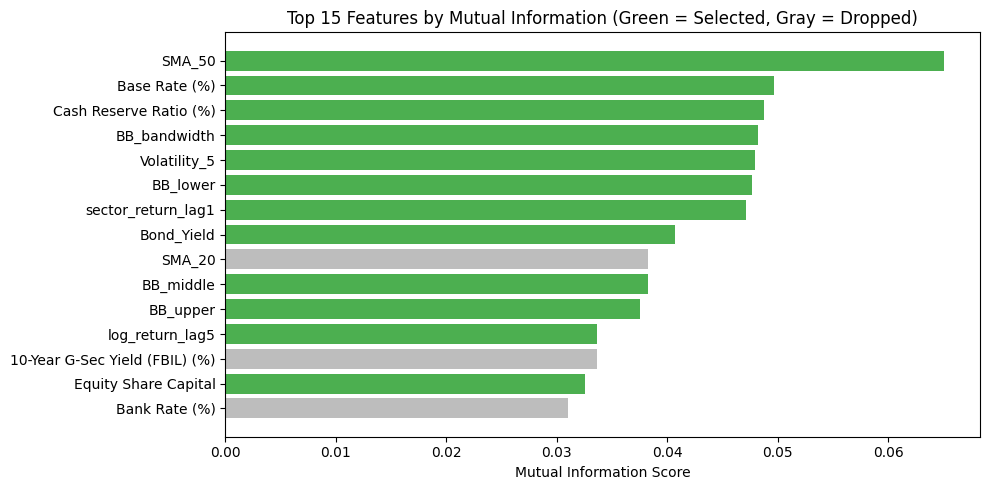


Interaction candidates (after adding back key domain features): ['Volume', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'SMA_50', 'RSI_14', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'Volatility_5', 'log_return_lag5', 'volume_lag2', 'VWAP', 'Basic EPS']
Creating interactions from top 6: ['SMA_50', 'Volatility_5', 'BB_lower', 'BB_upper', 'BB_bandwidth', 'BB_middle']
✅ Added 15 interaction features
   Total features for modeling: 43
Before rolling standardization: (1420, 95)
✅ Rolling standardization complete. Final rows: 1410
Final usable data range:
2020-03-26 00:00:00 → 2025-12-30 00:00:00

================ TIME SERIES CV ================

Fold 1 | RMSE: 0.015944 | R²: -0.0065 | Accuracy: 0.5040
Fold 2 | RMSE: 0.016268 | R²: -0.0077 | Accuracy: 0.5159
Fold 3 | RMSE: 0.010253 | R²: -0.0063 | Accuracy: 0.5159
Fold 4 | RMSE: 0.014050 | R²: 0.0023 | Accuracy: 0.5397
Fold 5 | RMSE: 0.009717 | R²: 0.0049 | Accuracy: 0.4960

CV Mean RMSE: 0.01324629828034

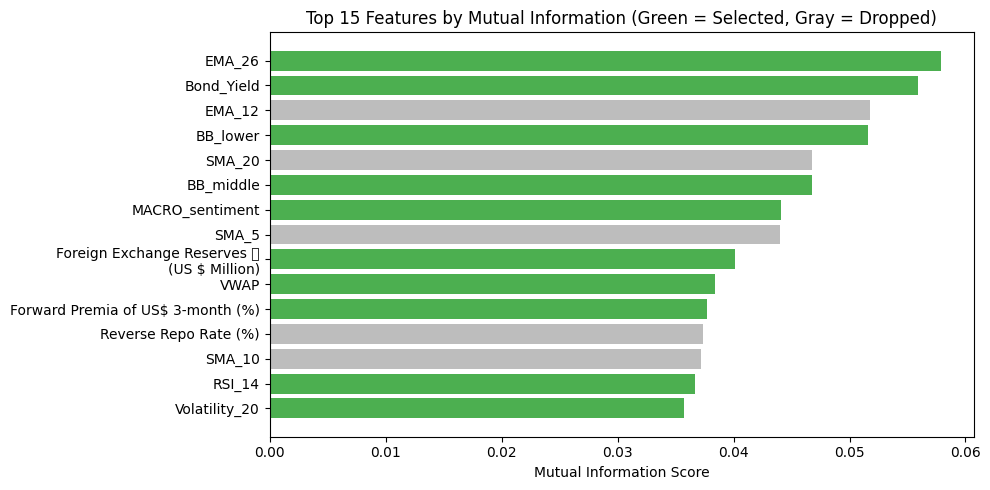


Interaction candidates (after adding back key domain features): ['Volume', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'EMA_26', 'RSI_14', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'Volatility_20', 'log_return_lag3', 'volume_lag2', 'VWAP', 'Basic EPS']
Creating interactions from top 6: ['EMA_26', 'Volatility_20', 'Foreign Exchange Reserves \r\n(US $ Million)', 'BB_middle', 'BB_lower', 'VWAP']
✅ Added 15 interaction features
   Total features for modeling: 44
Before rolling standardization: (1420, 99)
✅ Rolling standardization complete. Final rows: 1410
Final usable data range:
2020-03-26 00:00:00 → 2025-12-30 00:00:00

================ TIME SERIES CV ================

Fold 1 | RMSE: 0.020745 | R²: -0.0257 | Accuracy: 0.5079
Fold 2 | RMSE: 0.018349 | R²: -0.0057 | Accuracy: 0.5397
Fold 3 | RMSE: 0.014442 | R²: -0.0175 | Accuracy: 0.5437
Fold 4 | RMSE: 0.019391 | R²: 0.0044 | Accuracy: 0.5397
Fold 5 | 

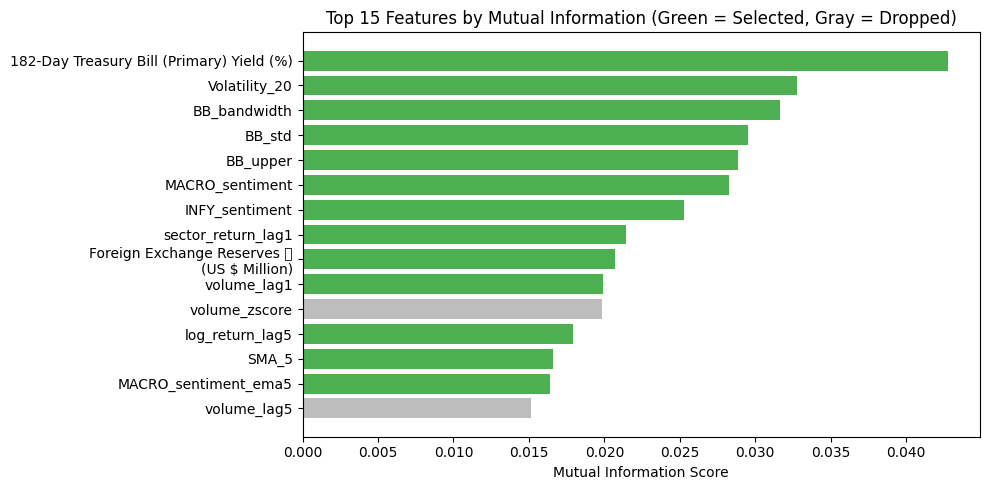


Interaction candidates (after adding back key domain features): ['Volume', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'SMA_5', 'MACD', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'Volatility_20', 'log_return_lag5', 'volume_lag1', 'VWAP', 'Basic EPS']
Creating interactions from top 6: ['BB_bandwidth', 'BB_std', 'volume_lag1', 'Volatility_20', 'sector_return_lag1', 'SMA_5']
✅ Added 15 interaction features
   Total features for modeling: 46
Before rolling standardization: (1420, 99)
✅ Rolling standardization complete. Final rows: 1410
Final usable data range:
2020-03-26 00:00:00 → 2025-12-30 00:00:00

================ TIME SERIES CV ================

Fold 1 | RMSE: 0.013718 | R²: -0.0041 | Accuracy: 0.5675
Fold 2 | RMSE: 0.017606 | R²: -0.0150 | Accuracy: 0.5278
Fold 3 | RMSE: 0.014535 | R²: -0.0167 | Accuracy: 0.4960
Fold 4 | RMSE: 0.014678 | R²: 0.0149 | Accuracy: 0.5357
Fold 5 | RMSE: 0.015292 | R²: 0

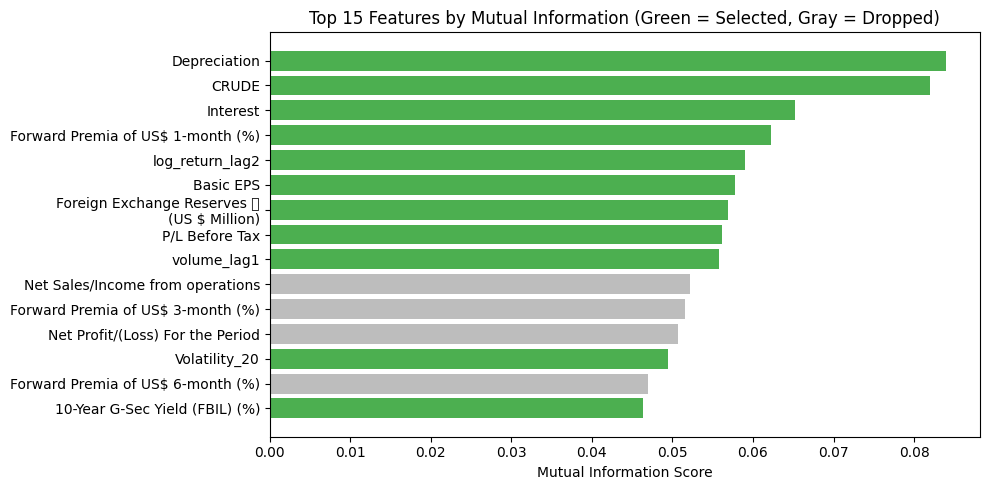


Interaction candidates (after adding back key domain features): ['Volume', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'SMA_20', 'RSI_14', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'Volatility_20', 'log_return_lag2', 'volume_lag1', 'VWAP', 'Basic EPS']
Creating interactions from top 6: ['Basic EPS', 'volume_lag1', 'log_return_lag2', 'Foreign Exchange Reserves \r\n(US $ Million)', 'BB_middle', 'SMA_20']
✅ Added 15 interaction features
   Total features for modeling: 41
Before rolling standardization: (1420, 99)
✅ Rolling standardization complete. Final rows: 1410
Final usable data range:
2020-03-26 00:00:00 → 2025-12-30 00:00:00

================ TIME SERIES CV ================

Fold 1 | RMSE: 0.012937 | R²: -0.0083 | Accuracy: 0.4563
Fold 2 | RMSE: 0.015076 | R²: 0.0304 | Accuracy: 0.5952
Fold 3 | RMSE: 0.009992 | R²: 0.0044 | Accuracy: 0.5278
Fold 4 | RMSE: 0.013085 | R²: -0.0028 | Accuracy: 0.4960


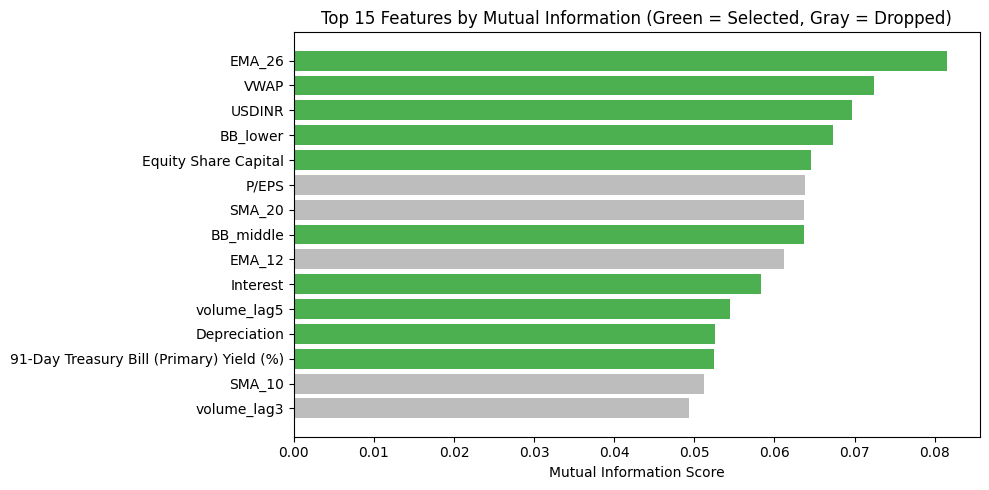


Interaction candidates (after adding back key domain features): ['Volume', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'EMA_26', 'MACD_signal', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_pct', 'Volatility_5', 'log_return_lag1', 'volume_lag5', 'VWAP', 'Basic EPS']
Creating interactions from top 6: ['BB_lower', 'EMA_26', 'VWAP', 'BB_middle', 'volume_lag5', 'BB_upper']
✅ Added 15 interaction features
   Total features for modeling: 46
Before rolling standardization: (1420, 99)
✅ Rolling standardization complete. Final rows: 1410
Final usable data range:
2020-03-26 00:00:00 → 2025-12-30 00:00:00

================ TIME SERIES CV ================

Fold 1 | RMSE: 0.017787 | R²: -0.0148 | Accuracy: 0.4921
Fold 2 | RMSE: 0.015527 | R²: -0.0023 | Accuracy: 0.5238
Fold 3 | RMSE: 0.010560 | R²: -0.0005 | Accuracy: 0.4802
Fold 4 | RMSE: 0.014629 | R²: -0.0083 | Accuracy: 0.5476
Fold 5 | RMSE: 0.012040 | R²: 0.0107 | Accuracy: 0.5397

CV Mean RMSE: 0.014108567264251665
CV M

In [32]:
stocks = {
    "RELIANCE": reliance_ml_data,
    "HDFC": HDFC_ml_data,
    "MM": MM_ml_data,
    "INFY": INFY_ml_data,
    "HUL": HUL_ml_data,
    "BHARTI": BHARTIARTL_ml_data
}

results_summary = []

for name, data in stocks.items():

    prepared = prepare_stock_dataframe(data, name, target_type="raw")

    r2, acc, _, _, _, _ = train_stock_model(prepared, name)

    results_summary.append({
        "Stock": name,
        "R2": r2,
        "Accuracy": acc
    })

results_df = pd.DataFrame(results_summary)
print("\nFINAL SUMMARY")
print(results_df)